In [1]:
import numpy as np
from matplotlib import pyplot as plt
from cycler import cycler
plt.rc('axes', prop_cycle=cycler(color=['0.0', '0.4', '0.8']))
import matplotlib; matplotlib.rcParams.update({'font.size': 18})

In [2]:
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
import course_helpers as chh
import ml_helpers as mlh
apply_beamer_theme(
    "madrid", skip_font_download=True, author="Robert Pettis", date="Fall 2026",
    show_slide_number=True, cell_tags=True, notebook_path="09-Ensembles-of-Trees.ipynb",
)

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 38 cell(s):
 cell_index   slide_id                                  tags
          9  slide-1-0 slide_hide_prompt, slide_remove_input
         11  slide-1-1 slide_hide_prompt, slide_remove_input
         13  slide-1-2 slide_hide_prompt, slide_remove_input
         15  slide-1-3 slide_hide_prompt, slide_remove_input
         17  slide-1-4 slide_hide_prompt, slide_remove_input
         19  slide-1-5 slide_hide_prompt, slide_remove_input
         21  slide-1-6 slide_hide_prompt, slide_remove_input
         23  slide-1-7 slide_hide_prompt, slide_remove_input
         25  slide-1-8 slide_hide_prompt, slide_remove_input
         27  slide-1-9 slide_hide_prompt, slide_remove_input
         29 slide-1-10 slide_hide_prompt, slide_remove_input
         32 slide-1-12 slide_hide_prompt, slide_remove_input
         34 slide-1-13 slide_hide_prompt, slide_remove_input
         36 slide-1-14 slide_hide_prompt, slide_remove_input
         38  slide-2-0 slide_hide_prompt, sli

In [3]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

In [4]:
# One place that knows how to draw the pictures this deck needs: his data
# tables, a box and arrow tree, and the little nameless trees a forest is
# made of. Every slide below supplies only its own numbers.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import course_helpers as chh

Q_FILL, LEAF_FILL = chh.ACCENT, "#2E8B57"
GREY_HEAD, GREY_TEXT = "#AEB4C7", "#C2C6D2"

# --------------------------------------------------------------- his patients
HD_HEAD = ["Chest\nPain", "Good\nBlood\nCirc.", "Blocked\nArteries", "Weight",
           "Heart\nDisease"]
HD_ROWS = [("No",  "No",  "No",  "125", "No"),
           ("Yes", "Yes", "Yes", "180", "Yes"),
           ("Yes", "Yes", "No",  "210", "No"),
           ("Yes", "No",  "Yes", "167", "Yes")]
PICKS = [1, 0, 3, 3]          # the fourth draw repeats the third
OOB = 2                       # the row that never got drawn
BOOT = [HD_ROWS[k] for k in PICKS]
BLANK = ("", "", "", "", "")

# ------------------------------------------ his eight patients for AdaBoost
AB_HEAD = ["Chest\nPain", "Blocked\nArteries", "Patient\nWeight",
           "Heart\nDisease", "Sample\nWeight"]
AB_ROWS = [("Yes", "Yes", "205", "Yes"),
           ("No",  "Yes", "180", "Yes"),
           ("Yes", "No",  "210", "Yes"),
           ("Yes", "Yes", "167", "Yes"),
           ("No",  "Yes", "156", "No"),
           ("No",  "Yes", "125", "No"),
           ("Yes", "No",  "168", "No"),
           ("Yes", "Yes", "172", "No")]
AB_WRONG = 3            # the 167 pound patient the first stump gets wrong
AB_PINK = "#B0286B"     # the sample weight column keeps a colour of its own


def gini(groups):
    """Weighted Gini impurity for a split. groups is a list of (yes, no)
       counts, one pair per leaf."""
    n = float(sum(a + b for a, b in groups))
    return sum((a + b) / n * (1 - (a / (a + b)) ** 2 - (b / (a + b)) ** 2)
               for a, b in groups if a + b)


def say(total_error):
    """How much say a stump gets, given the weight it gets wrong."""
    return 0.5 * np.log((1 - total_error) / total_error)


def blank_ax(ax):
    ax.set_facecolor("white")
    ax.axis("off")


def data_table(ax, rows, head=None, left=0.0, top=0.0, cw=1.18, rh=0.50,
               hh=1.05, target=4, grey=(), ring_rows=(), ring_cols=(),
               fs=8.5, caption=None, head_colors=None, ring_cells=()):
    """One of his tables, drawn in data units so a tree can sit beside it.
       grey: columns already used, faded out. ring_rows, ring_cols and
       ring_cells: what the red circle is around on this slide."""
    head = HD_HEAD if head is None else head
    n = len(head)
    for j, h in enumerate(head):
        fc = (GREY_HEAD if j in grey else
              chh.FITLINE if j == target else chh.MADRID)
        fc = (head_colors or {}).get(j, fc)
        ax.add_patch(plt.Rectangle((left + j * cw, top - hh), cw, hh,
                                   facecolor=fc, edgecolor="white", lw=1.2,
                                   zorder=3))
        ax.text(left + (j + .5) * cw, top - hh / 2, h, ha="center", va="center",
                fontsize=fs - 0.8, color="white", weight="bold", zorder=4,
                linespacing=1.15)
    for i, row in enumerate(rows):
        yb = top - hh - (i + 1) * rh
        for j in range(n):
            ax.add_patch(plt.Rectangle((left + j * cw, yb), cw, rh,
                                       facecolor="#EEF1F8" if i % 2 else "#FFFFFF",
                                       edgecolor="white", lw=1.0, zorder=3))
            v = str(row[j]) if j < len(row) else ""
            ax.text(left + (j + .5) * cw, yb + rh / 2, v, ha="center",
                    va="center", fontsize=fs, zorder=4,
                    color=GREY_TEXT if j in grey else chh.INK)
    for i in ring_rows:
        yb = top - hh - (i + 1) * rh
        ax.add_patch(FancyBboxPatch((left + .05, yb + .05), n * cw - .10,
                                    rh - .10, boxstyle="round,pad=0.04",
                                    facecolor="none", edgecolor=chh.FITLINE,
                                    lw=2.0, zorder=6))
    for j in ring_cols:
        ax.add_patch(FancyBboxPatch((left + j * cw + .06, top - hh + .06),
                                    cw - .12, hh - .12,
                                    boxstyle="round,pad=0.04", facecolor="none",
                                    edgecolor=chh.FITLINE, lw=2.2, zorder=6))
    for i, j in ring_cells:
        ax.add_patch(FancyBboxPatch((left + j * cw + .06,
                                     top - hh - (i + 1) * rh + .05),
                                    cw - .12, rh - .10,
                                    boxstyle="round,pad=0.03", facecolor="none",
                                    edgecolor=chh.FITLINE, lw=2.0, zorder=6))
    if caption:
        ax.text(left + n * cw / 2, top + .16, caption, ha="center", va="bottom",
                fontsize=fs + 2.0, color=chh.MADRID, weight="bold")
    return dict(left=left, right=left + n * cw, top=top,
                bottom=top - hh - len(rows) * rh, cw=cw, rh=rh, hh=hh,
                row=lambda i: top - hh - (i + .5) * rh,
                col=lambda j: left + (j + .5) * cw)


def node_box(ax, x, y, label, kind="q", fs=9.0, w=None, h=0.44, ring=False):
    """A single tree node, placed where you ask rather than where a layout
       engine wants it, so tables and trees can share one picture."""
    if w is None:
        w = 0.155 * max(len(t) for t in label.split("\n")) + 0.55
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle="round,pad=0.08",
                                facecolor=Q_FILL if kind == "q" else LEAF_FILL,
                                edgecolor=chh.FITLINE if ring else chh.INK,
                                lw=2.4 if ring else 1.2, zorder=4))
    ax.text(x, y, label, ha="center", va="center", fontsize=fs, color="white",
            weight="bold", zorder=5, linespacing=1.1)
    return w


def link(ax, a, b, label=None, red=False, fs=7.5, h=0.60):
    """An arrow from the bottom of one node to the top of the next."""
    col = chh.FITLINE if red else chh.INK
    ax.annotate("", xy=(b[0], b[1] + h / 2), xytext=(a[0], a[1] - h / 2),
                arrowprops=dict(arrowstyle="-|>", color=col, mutation_scale=13,
                                lw=2.2 if red else 1.4), zorder=6)
    if label:
        ax.text((a[0] + b[0]) / 2 + (-.18 if b[0] < a[0] else .18),
                (a[1] + b[1]) / 2, label, ha="center", va="center", fontsize=fs,
                color=col, zorder=8,
                bbox=dict(boxstyle="round,pad=0.14", facecolor="white",
                          edgecolor="none"))


def curve(ax, frm, to, rad=-0.3, red=True, lw=1.6):
    """The red swoop he draws from a row to where it lands."""
    ax.annotate("", xy=to, xytext=frm, zorder=7,
                arrowprops=dict(arrowstyle="-|>", lw=lw,
                                color=chh.FITLINE if red else chh.INK,
                                connectionstyle="arc3,rad=%g" % rad))


def mini_tree(ax, ox, oy, seed, pitch=0.56, drop=0.50, bw=0.38, bh=0.16):
    """One of the small nameless trees a forest is drawn as. Orange asks,
       green answers. The shape is random, so no two of them match. ox is the
       centre of the tree, not its left edge, so a row of them lines up."""
    for attempt in range(40):
        rng = np.random.default_rng(seed + 1000 * attempt)
        nodes, edges, order = [], [], []

        def grow(depth):
            i = len(nodes)
            nodes.append([0.0, depth, "leaf"])
            chance = 1.0 if depth == 0 else (0.62 if depth == 1 else 0.28)
            if depth < 3 and rng.random() < chance:
                nodes[i][2] = "q"
                for _ in range(2):
                    edges.append((i, grow(depth + 1)))
            return i

        grow(0)

        def place(i):
            kids = [b for a, b in edges if a == i]
            if not kids:
                nodes[i][0] = float(len(order))
                order.append(i)
            else:
                for b in kids:
                    place(b)
                nodes[i][0] = sum(nodes[b][0] for b in kids) / len(kids)

        place(0)
        if 3 <= len(order) <= 5:
            break

    span = float(len(order) - 1)
    deep = max(n[1] for n in nodes)

    def xy(n):
        return ox + (n[0] - span / 2) * pitch, oy - n[1] * drop

    for a, b in edges:
        x1, y1 = xy(nodes[a])
        x2, y2 = xy(nodes[b])
        ax.annotate("", xy=(x2, y2 + bh / 2), xytext=(x1, y1 - bh / 2),
                    arrowprops=dict(arrowstyle="-|>", color=chh.INK, lw=1.0,
                                    mutation_scale=7))
    for n in nodes:
        x, y = xy(n)
        ax.add_patch(plt.Rectangle((x - bw / 2, y - bh / 2), bw, bh, zorder=4,
                                   facecolor=Q_FILL if n[2] == "q" else LEAF_FILL,
                                   edgecolor=chh.INK, lw=0.6))
    return dict(left=ox - (span / 2) * pitch - bw / 2, top=oy + bh / 2,
                right=ox + (span / 2) * pitch + bw / 2, mid=ox,
                bottom=oy - deep * drop - bh / 2)


def stump(ax, cx, cy, question, left, right, gap=3.4, drop=1.25, hot=None,
          fs=7.6, lw=2.4):
    """A node and two leaves, each leaf carrying the tally he writes in it.
       left and right are (what the leaf says, how many it gets right, how
       many it gets wrong). lw is the leaf width in data units, which has to
       be set by the caller since these panels are scaled differently."""
    node_box(ax, cx, cy, question, fs=fs + 1.4)
    made = []
    for k, (side, spec) in enumerate(zip((-1, 1), (left, right))):
        x = cx + side * gap / 2
        lab = "%s\n%d right,  %d wrong" % spec
        node_box(ax, x, cy - drop, lab, kind="leaf", fs=fs, h=0.72, w=lw,
                 ring=(hot == k))
        link(ax, (cx, cy), (x, cy - drop), h=0.80)
        made.append((x, cy - drop))
    return made


def mini_stump(ax, x, y, scale=1.0, bw=0.52, bh=0.20, gap=0.80, drop=0.52):
    """A stump drawn at whatever size its say is worth."""
    bw, bh, gap, drop = bw * scale, bh * scale, gap * scale, drop * scale
    ax.add_patch(plt.Rectangle((x - bw / 2, y - bh / 2), bw, bh, zorder=4,
                               facecolor=Q_FILL, edgecolor=chh.INK, lw=0.7))
    for s in (-1, 1):
        xx = x + s * gap / 2
        ax.annotate("", xy=(xx, y - drop + bh / 2), xytext=(x, y - bh / 2),
                    arrowprops=dict(arrowstyle="-|>", color=chh.INK, lw=1.0,
                                    mutation_scale=7))
        ax.add_patch(plt.Rectangle((xx - bw / 2, y - drop - bh / 2), bw, bh,
                                   facecolor=LEAF_FILL, edgecolor=chh.INK,
                                   lw=0.7, zorder=4))
    return dict(bottom=y - drop - bh / 2, left=x - gap / 2 - bw / 2,
                right=x + gap / 2 + bw / 2)


def vote_box(ax, x, y, yes, no, w=0.95, hh=0.40, rh=0.38, fs=9.0):
    """His scoreboard: the question on top, the tally underneath."""
    ax.add_patch(plt.Rectangle((x, y - hh), 2 * w, hh, facecolor=LEAF_FILL,
                               edgecolor="white", lw=1.2, zorder=3))
    ax.text(x + w, y - hh / 2, "Heart Disease", ha="center", va="center",
            fontsize=fs - 0.5, color="white", weight="bold", zorder=4)
    for k, (lab, v) in enumerate((("Yes", yes), ("No", no))):
        ax.add_patch(plt.Rectangle((x + k * w, y - hh - rh), w, rh, zorder=3,
                                   facecolor=LEAF_FILL, edgecolor="white", lw=1.2))
        ax.text(x + (k + .5) * w, y - hh - rh / 2, lab, ha="center",
                va="center", fontsize=fs - 1, color="white", zorder=4)
        ax.add_patch(plt.Rectangle((x + k * w, y - hh - 2 * rh), w, rh, zorder=3,
                                   facecolor="#FFFFFF", edgecolor="#C8CCD8", lw=1.0))
        ax.text(x + (k + .5) * w, y - hh - 1.5 * rh, str(v), ha="center",
                va="center", fontsize=fs + 1.5, color=chh.INK, weight="bold",
                zorder=4)
    return dict(left=x, right=x + 2 * w, bottom=y - hh - 2 * rh)


def frame(figsize, xlim, ylim, dpi=110):
    """A blank white panel with the limits set by hand, since these pictures
       are laid out in data units and must not be autoscaled."""
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("white")
    blank_ax(ax)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    return fig, ax


def note(ax, x, y, text, fs=10.0, ha="left", va="center", color=None):
    ax.text(x, y, text, ha=ha, va=va, fontsize=fs, linespacing=1.35,
            color=color or chh.INK, zorder=8)


# ------------------------------------------------- a file to turn the dial on
def loan_data(n=800, p=20, seed=7):
    """A simulated default file: twenty household variables, of which five
       carry the signal and fifteen are noise. Used only where we need a data
       set big enough to actually measure an out of bag error."""
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))
    beta = np.zeros(p)
    beta[:5] = [1.4, -1.1, 0.9, -0.8, 0.6]
    z = X @ beta + 0.9 * X[:, 0] * X[:, 1] + rng.normal(scale=0.9, size=n)
    return X, (z > 0).astype(int)

# Ensembles of Trees

### One tree guesses. A forest votes

Causal Machine Learning

## Before We Start: Updating Your Repo

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Reminder</span> &nbsp;same git rhythm as the setup lecture.

| command | what it does |
|---|---|
| `git pull upstream main` | grab today's lecture before class |
| `git checkout -b ps1` | a branch for your own work |
| `git add .` then `git commit -m "..."` | snapshot your changes |
| `git push origin ps1` | send it to your fork, then open a pull request |
| `git status` | what changed, any time |

### Last Time: Decision Trees

- A tree is a run of true or false questions ending in a <b style="color:#73000A;">leaf</b>
- Classification splits on <b style="color:#73000A;">Gini impurity</b>, regression on the <b style="color:#73000A;">sum of squared residuals</b>
- The prediction is <b style="color:#73000A;">flat inside a leaf</b>, so a tree cannot extrapolate
- One deep tree fits the patients it was built from and misses the next one

### Where We Are Going

- <b style="color:#73000A;">Random forests</b>: build hundreds of trees on resampled data and let them vote
- <b style="color:#73000A;">AdaBoost</b>: a crowd of one-split stumps, each one fixing what the last got wrong
- <b style="color:#73000A;">Gradient boosting</b>: small trees fitted to the leftovers, added on a little at a time
- <b style="color:#73000A;">XGBoost</b> and friends: the same idea, engineered to run on real files
- Forests come back later as <b style="color:#73000A;">causal forests</b>, which is the whole reason trees are in this course

## Trees Are Easy. They Are Also Not That Good

> Trees have one aspect that prevents them from being the ideal tool for
> predictive learning, namely inaccuracy.

- Easy to build, easy to read, and they work great on the observations they were trained from. 

- Could be better with new data.

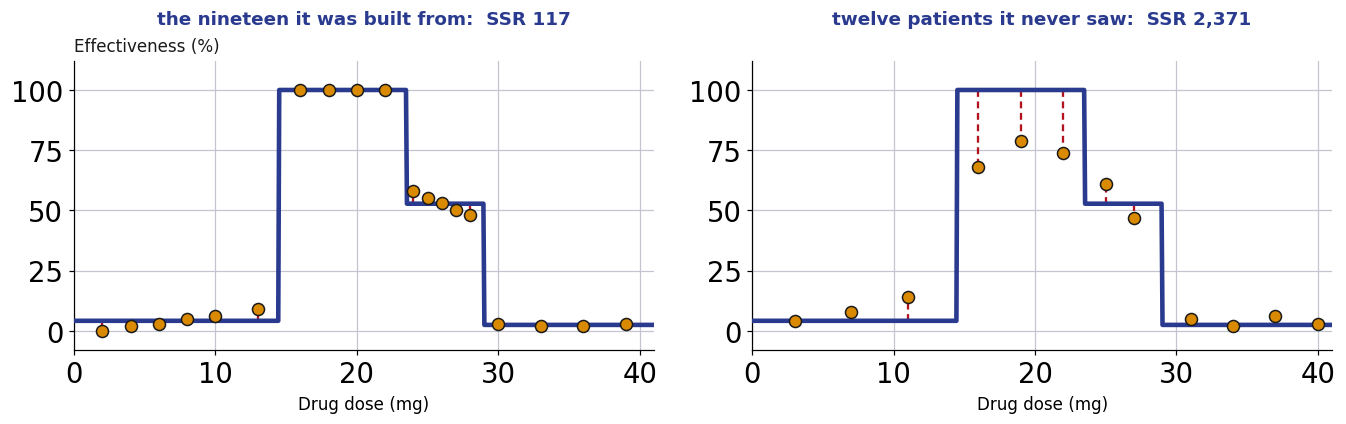

In [5]:
DOSE, EFF = mlh._DT_DOSE, mlh._DT_EFF
ND = np.array([3, 7, 11, 16, 19, 22, 25, 27, 31, 34, 37, 40], float)
NE = np.array([4, 8, 14, 68, 79, 74, 61, 47, 5, 2, 6, 3], float)
CUT = [0, 14.5, 23.5, 29, 41]


def leaves(ed, at):
    out = np.empty(len(at), float)
    for lo, hi in zip(ed[:-1], ed[1:]):
        m = (DOSE >= lo) & (DOSE < hi)
        out[(at >= lo) & (at < hi)] = EFF[m].mean()
    return out


g = np.linspace(0, 40.99, 600)
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2), dpi=110)
fig.patch.set_facecolor("white")
for ax, (d, e, head) in zip(axes, ((DOSE, EFF, "the nineteen it was built from"),
                                   (ND, NE, "twelve patients it never saw"))):
    ax.set_facecolor("white")
    ax.grid(True, color=chh.GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.plot(g, leaves(CUT, g), lw=3.0, color=chh.MADRID, zorder=4)
    fitted = leaves(CUT, d)
    ax.vlines(d, fitted, e, color=chh.FITLINE, lw=1.5, ls=(0, (3, 2)), zorder=3)
    ax.scatter(d, e, s=62, color=chh.ACCENT, edgecolors=chh.INK, lw=1.0, zorder=5)
    ax.set_title("%s:  SSR %s" % (head, format(((e - fitted) ** 2).sum(), ",.0f")),
                 fontsize=12, color=chh.MADRID, weight="bold", pad=24)
    ax.set_xlabel("Drug dose (mg)", fontsize=11)
    ax.set_xlim(0, 41)
    ax.set_ylim(-8, 112)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
axes[0].text(0, 1.02, "Effectiveness (%)", transform=axes[0].transAxes,
             ha="left", va="bottom", fontsize=11, color=chh.INK)
fig.tight_layout()

### Step 1: Make a Bootstrapped Data Set

Four patients, four columns to ask about, and one column we are trying to
predict. Crazy small, but pretend it is everything we have.

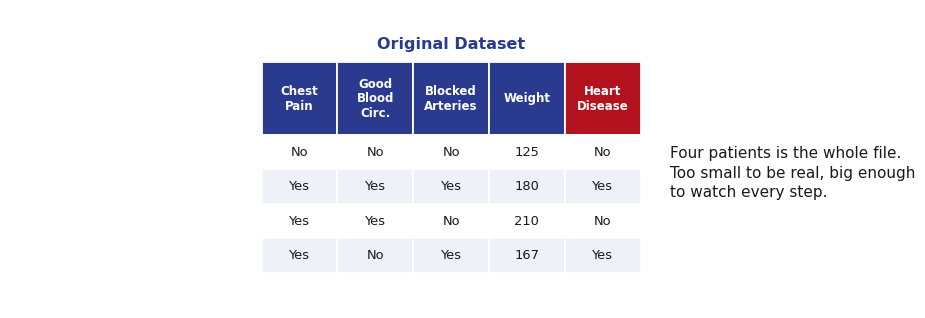

In [6]:
fig, ax = frame((10.4, 3.5), (-3.9, 9.9), (-3.55, 0.75))
t = data_table(ax, HD_ROWS, left=0.0, top=0.0, caption="Original Dataset")
note(ax, t["right"] + 0.45, -1.6,
     "Four patients is the whole file.\nToo small to be real, big enough\nto watch every step.")

### Draw a Patient at Random (WITH REPLACEMENT)

A bootstrapped data set is the <b style="color:#73000A;">same size</b> as the original. You draw rows
out of it at random, and you are allowed to draw the same row more than once.

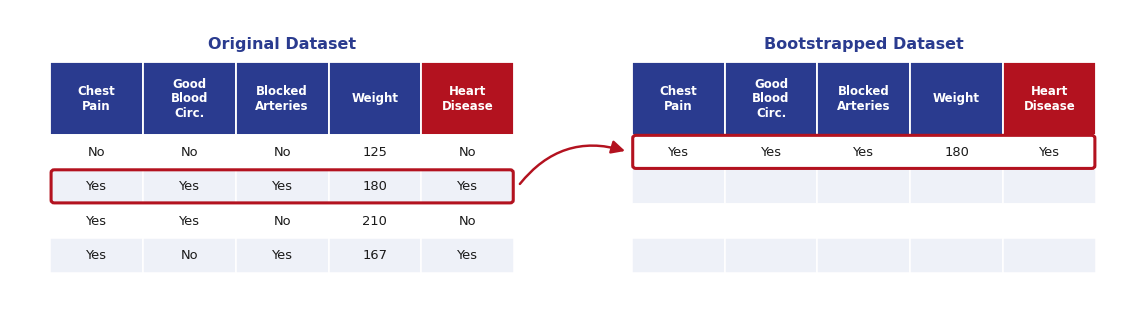

In [7]:
fig, ax = frame((13.0, 3.5), (-0.5, 13.6), (-3.55, 0.75))
L = data_table(ax, HD_ROWS, left=0.0, top=0.0, ring_rows=[1],
               caption="Original Dataset")
R = data_table(ax, [BOOT[0], BLANK, BLANK, BLANK], left=7.4, top=0.0,
               ring_rows=[0], caption="Bootstrapped Dataset")
curve(ax, (L["right"] + 0.05, L["row"](1)), (R["left"] - 0.05, R["row"](0)),
      rad=-0.35)

### Keep Drawing Until You Have Four

- The fourth draw came up the same as the third. 
- We are bootstraping WITH REPLACEMENT so this is allowed.

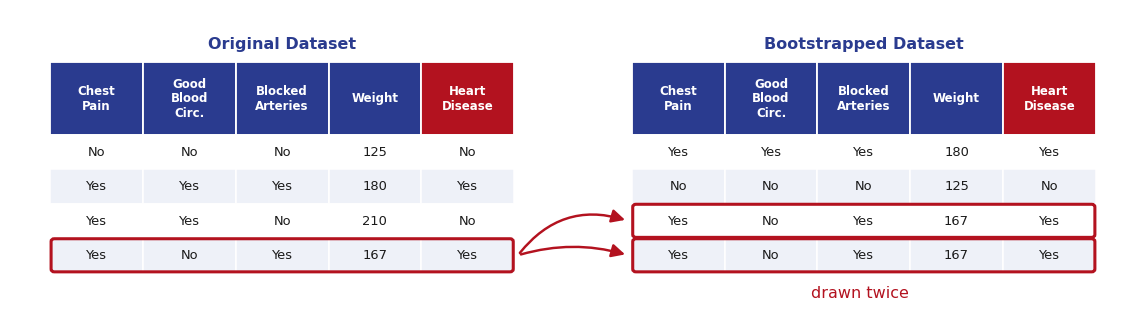

In [8]:
fig, ax = frame((13.0, 3.5), (-0.5, 13.6), (-3.55, 0.75))
L = data_table(ax, HD_ROWS, left=0.0, top=0.0, ring_rows=[3],
               caption="Original Dataset")
R = data_table(ax, BOOT, left=7.4, top=0.0, ring_rows=[2, 3],
               caption="Bootstrapped Dataset")
for i in (2, 3):
    curve(ax, (L["right"] + 0.05, L["row"](3)), (R["left"] - 0.05, R["row"](i)),
          rad=-0.35 if i == 2 else -0.15)
note(ax, R["left"] + 2.9, -3.35, "drawn twice", fs=10.5, ha="center",
     color=chh.FITLINE)

### Step 2: Build a Tree, and Hide Most of the Columns

At <b style="color:#73000A;">every</b> node, pick a random two of the available columns and choose the
split from those two only. Here the draw came up blood circulation and
blocked arteries.

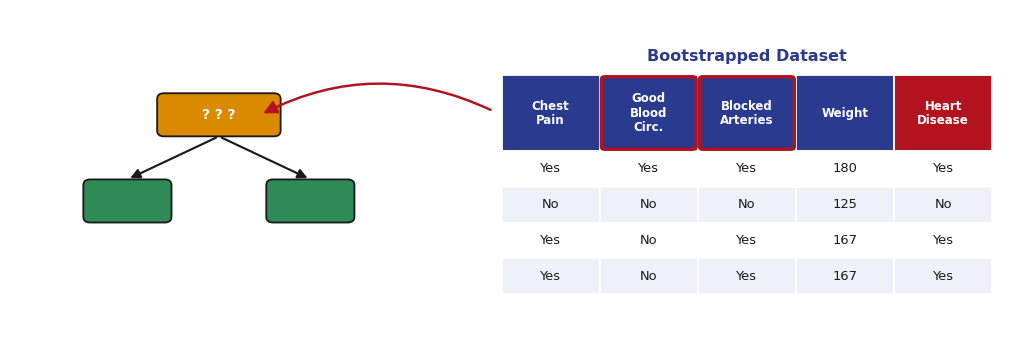

In [9]:
fig, ax = frame((11.9, 3.9), (-4.9, 7.3), (-3.7, 0.9))
T = data_table(ax, BOOT, left=1.0, top=0.0, ring_cols=[1, 2],
               caption="Bootstrapped Dataset")
node_box(ax, -2.4, -0.55, "? ? ?")
for x in (-3.5, -1.3):
    link(ax, (-2.4, -0.55), (x, -1.75))
    node_box(ax, x, -1.75, "        ", kind="leaf", w=0.9)
curve(ax, (T["left"] - 0.1, -0.5), (-2.4 + 0.5, -0.55), rad=0.25)

### Blood Circulation Wins the Root

- Same scoring as in Classification Trees:
 - Gini impurity on the two candidates it was offered.
- Once a column has been used, grey it out and move on.

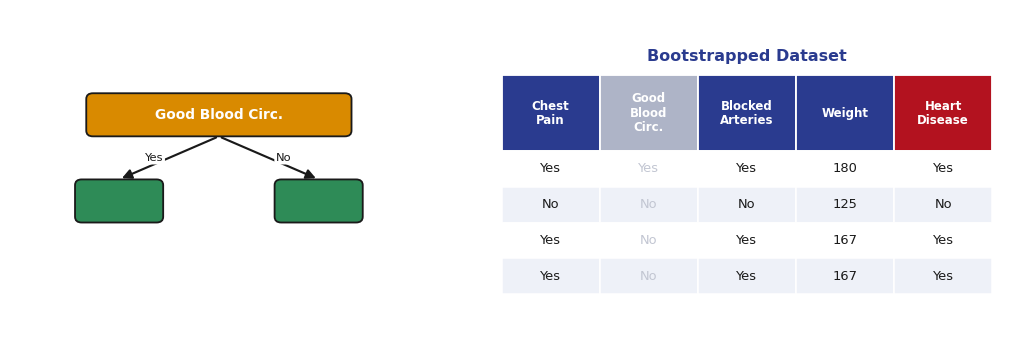

In [10]:
fig, ax = frame((11.9, 3.9), (-4.9, 7.3), (-3.7, 0.9))
T = data_table(ax, BOOT, left=1.0, top=0.0, grey=[1],
               caption="Bootstrapped Dataset")
node_box(ax, -2.4, -0.55, "Good Blood Circ.")
for x, lab in ((-3.6, "Yes"), (-1.2, "No")):
    link(ax, (-2.4, -0.55), (x, -1.75), lab)
    node_box(ax, x, -1.75, "        ", kind="leaf", w=0.9)

### Do It Again at the Next Node

Three columns left, so draw two of them. This time chest pain and weight.

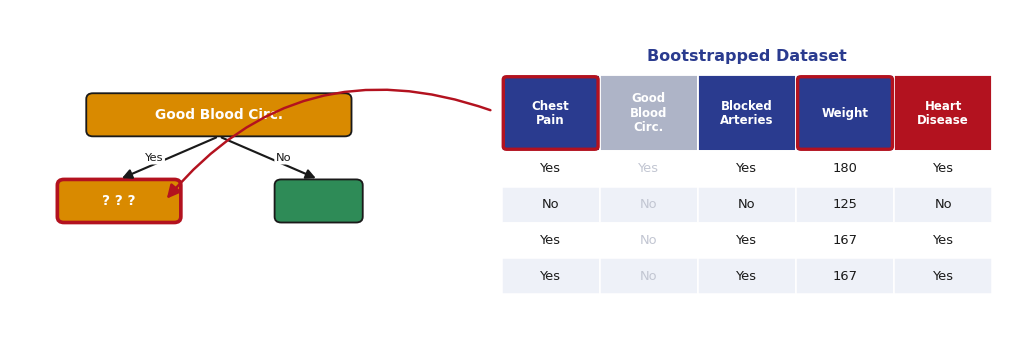

In [11]:
fig, ax = frame((11.9, 3.9), (-4.9, 7.3), (-3.7, 0.9))
T = data_table(ax, BOOT, left=1.0, top=0.0, grey=[1], ring_cols=[0, 3],
               caption="Bootstrapped Dataset")
node_box(ax, -2.4, -0.55, "Good Blood Circ.")
node_box(ax, -3.6, -1.75, "? ? ?", ring=True)
link(ax, (-2.4, -0.55), (-3.6, -1.75), "Yes")
link(ax, (-2.4, -0.55), (-1.2, -1.75), "No")
node_box(ax, -1.2, -1.75, "        ", kind="leaf", w=0.9)
curve(ax, (T["left"] - 0.1, -0.5), (-3.6 + 0.55, -1.75), rad=0.35)

### That Is One Tree

Built on a bootstrapped copy of the data, and choosing from a random handful
of columns at every step.

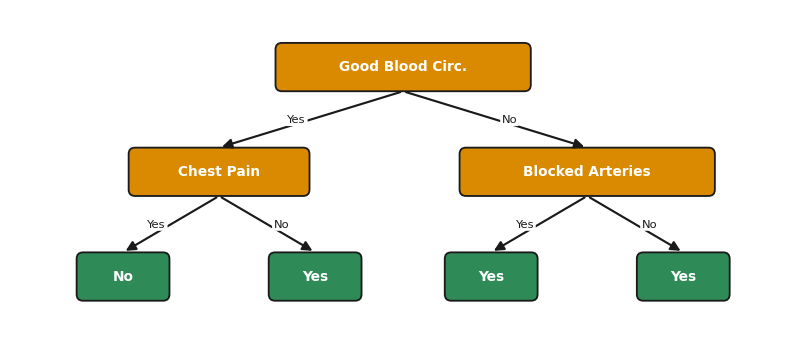

In [12]:
fig, ax = frame((9.2, 3.9), (-4.9, 4.9), (-3.4, 0.7))
node_box(ax, 0.0, 0.0, "Good Blood Circ.")
node_box(ax, -2.3, -1.3, "Chest Pain")
node_box(ax, 2.3, -1.3, "Blocked Arteries")
link(ax, (0, 0), (-2.3, -1.3), "Yes")
link(ax, (0, 0), (2.3, -1.3), "No")
for x, lab, side in ((-3.5, "No", "Yes"), (-1.1, "Yes", "No"),
                     (1.1, "Yes", "Yes"), (3.5, "Yes", "No")):
    link(ax, (2.3 if x > 0 else -2.3, -1.3), (x, -2.6), side)
    node_box(ax, x, -2.6, lab, kind="leaf", w=1.0)

### Now Go Back to Step 1 and Do It Again

A new bootstrap, a new set of random columns, a new tree. Do it hundreds of
times.

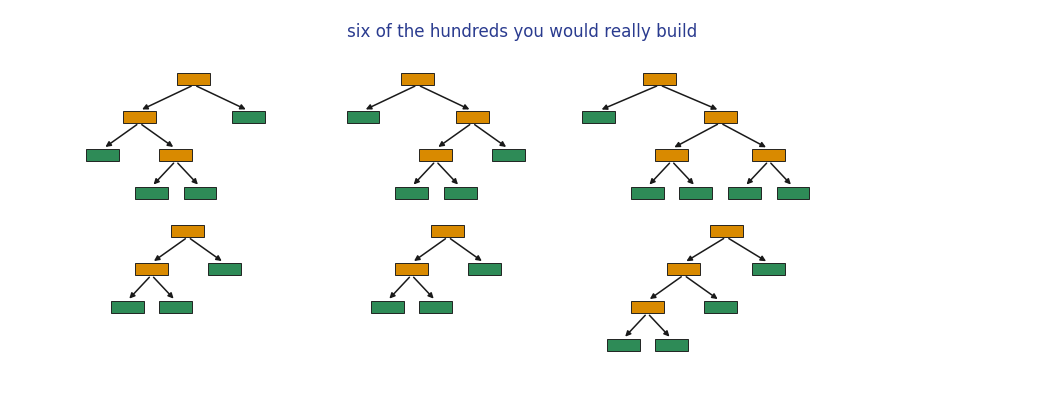

In [13]:
fig, ax = frame((12.0, 4.4), (-1.9, 9.9), (-4.0, 0.9))
for k in range(6):
    mini_tree(ax, (k % 3) * 3.0, -2.0 * (k // 3), seed=11 + 7 * k)
note(ax, 4.0, 0.62, "six of the hundreds you would really build", fs=11,
     ha="center", color=chh.MADRID)

### Using the Forest: Run the Patient Down Every Tree

A new patient turns up. Chest pain yes, blood circulation no, blocked arteries
no, weight 168. Nobody knows whether they have heart disease.

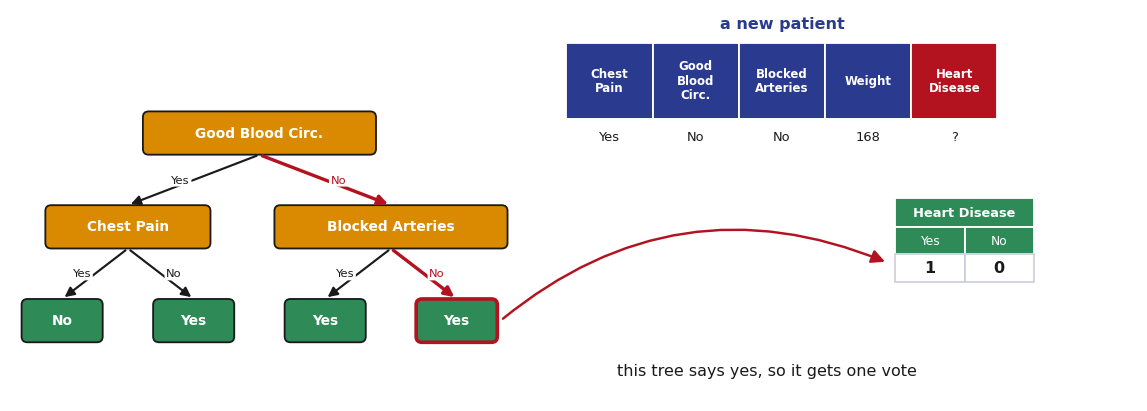

In [14]:
NEW = [("Yes", "No", "No", "168", "?")]
fig, ax = frame((13.2, 4.6), (-7.0, 8.4), (-3.9, 1.5))
data_table(ax, NEW, left=0.6, top=1.05, caption="a new patient")
node_box(ax, -3.6, -0.2, "Good Blood Circ.")
node_box(ax, -5.4, -1.5, "Chest Pain")
node_box(ax, -1.8, -1.5, "Blocked Arteries")
link(ax, (-3.6, -0.2), (-5.4, -1.5), "Yes")
link(ax, (-3.6, -0.2), (-1.8, -1.5), "No", red=True)
for x, lab, side, parent in ((-6.3, "No", "Yes", -5.4), (-4.5, "Yes", "No", -5.4),
                             (-2.7, "Yes", "Yes", -1.8), (-0.9, "Yes", "No", -1.8)):
    hot = parent == -1.8 and side == "No"
    link(ax, (parent, -1.5), (x, -2.8), side, red=hot)
    node_box(ax, x, -2.8, lab, kind="leaf", w=0.95, ring=hot)
v = vote_box(ax, 5.1, -1.1, 1, 0)
curve(ax, (-0.9 + 0.6, -2.8), (v["left"] - 0.1, -2.0), rad=-0.30)
note(ax, 1.3, -3.5, "this tree says yes, so it gets one vote", fs=10.5)

### Count the Votes

Five trees say yes, one says no. The forest says yes.

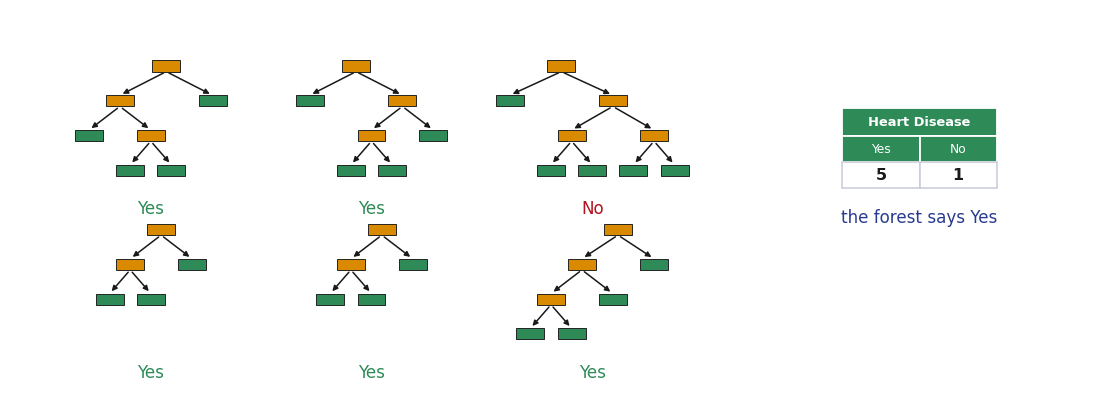

In [15]:
fig, ax = frame((12.6, 4.6), (-1.9, 12.7), (-4.8, 0.8))
SAY = ["Yes", "Yes", "No", "Yes", "Yes", "Yes"]
for k in range(6):
    top = -2.35 * (k // 3)
    g = mini_tree(ax, (k % 3) * 3.0, top, seed=11 + 7 * k)
    note(ax, g["mid"], top - 2.05, SAY[k], fs=11, ha="center",
         color=chh.FITLINE if SAY[k] == "No" else LEAF_FILL)
v = vote_box(ax, 9.4, -0.6, SAY.count("Yes"), SAY.count("No"), w=1.05)
note(ax, v["left"] + 1.05, v["bottom"] - 0.42, "the forest says Yes", fs=11,
     ha="center", color=chh.MADRID)

### The Word for This Is Bagging

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Terminology</span>

- <b style="color:#73000A;">B</b>ootstrap the rows, then <b style="color:#73000A;">agg</b>regate the answers. Bootstrap aggregating, shortened to <b style="color:#73000A;">bagging</b>
- A <b style="color:#73000A;">random forest</b> is bagging plus hiding most of the columns at each node
- Without that, one dominant variable takes the root of every tree and the trees all look alike

### About a Third of the Rows Never Get Drawn

- Drawing four rows out of four, with replacement, left one patient out. 
- This is pretty standard.

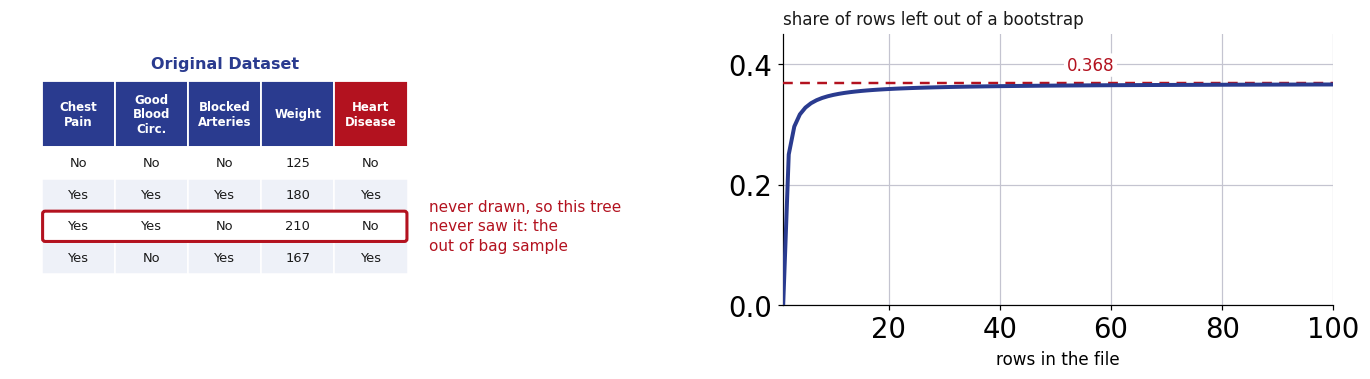

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 3.8), dpi=110,
                         gridspec_kw=dict(width_ratios=[1.25, 1.0]))
fig.patch.set_facecolor("white")
ax = axes[0]
blank_ax(ax)
ax.set_xlim(-0.5, 10.6)
ax.set_ylim(-3.55, 0.75)
L = data_table(ax, HD_ROWS, left=0.0, top=0.0, ring_rows=[OOB],
               caption="Original Dataset")
note(ax, L["right"] + 0.35, L["row"](OOB),
     "never drawn, so this tree\nnever saw it: the\nout of bag sample",
     fs=10, color=chh.FITLINE)

ax = axes[1]
ax.set_facecolor("white")
ax.grid(True, color=chh.GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
n = np.arange(1, 101)
ax.plot(n, (1 - 1 / n) ** n, lw=2.6, color=chh.MADRID, zorder=4)
ax.axhline(np.exp(-1), color=chh.FITLINE, lw=1.6, ls=(0, (4, 3)), zorder=3)
ax.text(52, np.exp(-1) + 0.022, "0.368", fontsize=11, color=chh.FITLINE,
        bbox=dict(boxstyle="round,pad=0.16", facecolor="white", edgecolor="none"),
        zorder=8)
ax.set_xlim(1, 100)
ax.set_ylim(0, 0.45)
ax.set_xlabel("rows in the file", fontsize=11)
ax.text(0, 1.02, "share of rows left out of a bootstrap", transform=ax.transAxes,
        ha="left", va="bottom", fontsize=11, color=chh.INK)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()

### Out of Bag Error

Run that patient through every tree that was built without them, and see
whether the forest gets it right.

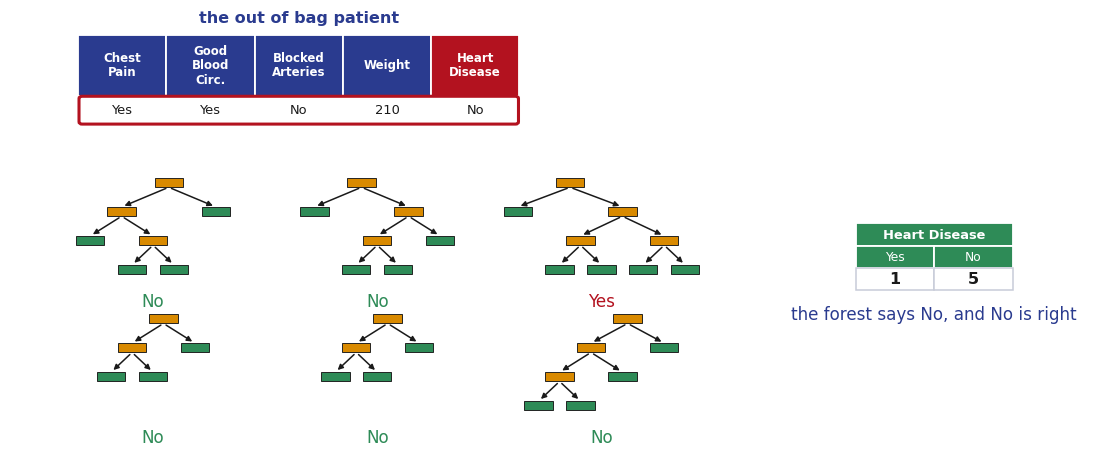

In [17]:
fig, ax = frame((12.8, 5.2), (-1.9, 12.7), (-6.2, 1.4))
data_table(ax, [HD_ROWS[OOB]], left=-1.0, top=1.05, ring_rows=[0],
           caption="the out of bag patient")
SAY = ["No", "No", "Yes", "No", "No", "No"]
for k in range(6):
    top = -1.5 - 2.35 * (k // 3)
    g = mini_tree(ax, (k % 3) * 3.0, top, seed=11 + 7 * k)
    note(ax, g["mid"], top - 2.05, SAY[k], fs=11, ha="center",
         color=chh.FITLINE if SAY[k] == "Yes" else LEAF_FILL)
v = vote_box(ax, 9.4, -2.2, SAY.count("Yes"), SAY.count("No"), w=1.05)
note(ax, v["left"] + 1.05, v["bottom"] - 0.42, "the forest says No, and No is right",
     fs=11, ha="center", color=chh.MADRID)

### Turning the Column Count Dial...

- How many columns do you offer at each node? Try a few, build a forest at each setting, and keep the one with the lowest out of bag error.
- A common place to start is the square root of the total number of columns available
  - Try a few numbers above and below that as well

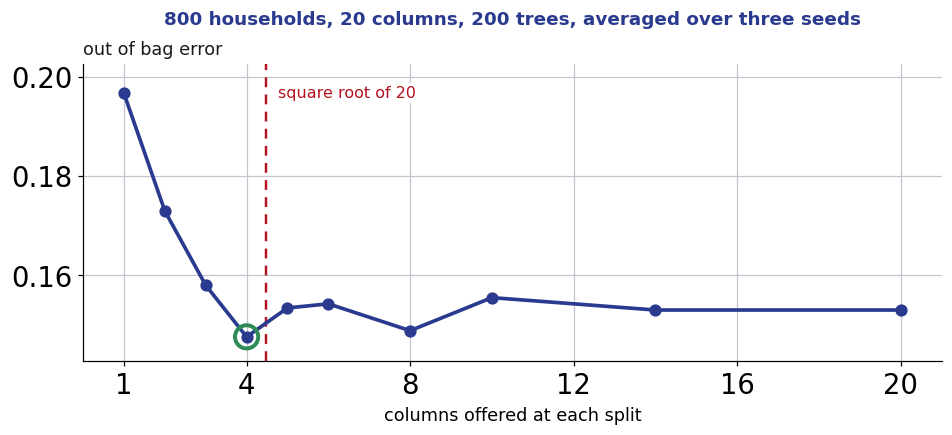

In [18]:
from sklearn.ensemble import RandomForestClassifier

X, y = loan_data()
p = X.shape[1]
tries = [1, 2, 3, 4, 5, 6, 8, 10, 14, 20]
err = [np.mean([1 - RandomForestClassifier(n_estimators=200, max_features=m,
                                           oob_score=True, random_state=s,
                                           n_jobs=-1).fit(X, y).oob_score_
                for s in (0, 1, 2)]) for m in tries]
best = tries[int(np.argmin(err))]
lo, hi = min(err), max(err)

fig, ax = plt.subplots(figsize=(9.0, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=chh.GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.plot(tries, err, "-o", lw=2.4, ms=7, color=chh.MADRID, zorder=4)
ax.axvline(np.sqrt(p), color=chh.FITLINE, lw=1.6, ls=(0, (4, 3)), zorder=3)
ax.text(np.sqrt(p) + 0.3, hi, "square root of 20", fontsize=10.5,
        color=chh.FITLINE, zorder=8, va="center",
        bbox=dict(boxstyle="round,pad=0.16", facecolor="white", edgecolor="none"))
ax.scatter([best], [lo], s=230, facecolors="none", edgecolors="#2E8B57",
           lw=2.6, zorder=6)
ax.set_xlim(0, 21)
ax.set_xticks([1, 4, 8, 12, 16, 20])
ax.set_ylim(lo - 0.1 * (hi - lo), hi + 0.12 * (hi - lo))
ax.set_xlabel("columns offered at each split", fontsize=11.5)
ax.set_title("800 households, 20 columns, 200 trees, averaged over three seeds",
             fontsize=12, color=chh.MADRID, weight="bold", pad=26)
ax.text(0, 1.02, "out of bag error", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=11.5, color=chh.INK)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()

### Random Forests in scikit-learn

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X, y = loan_data()

one = DecisionTreeClassifier(random_state=0).fit(X, y)
rf = RandomForestClassifier(n_estimators=500, max_features="sqrt",
                            oob_score=True, random_state=0, n_jobs=-1).fit(X, y)

print("%-34s %9s" % ("", "accuracy"))
print("%-34s %9s" % ("-" * 32, "-" * 8))
print("%-34s %9.3f" % ("one tree, on its own data", one.score(X, y)))
print("%-34s %9.3f" % ("the forest, on its own data", rf.score(X, y)))
print("%-34s %9.3f" % ("the forest, out of bag", rf.oob_score_))

                                    accuracy
--------------------------------    --------
one tree, on its own data              1.000
the forest, on its own data            1.000
the forest, out of bag                 0.851


## AdaBoost: A Crowd of Stumps

- AdaBoost is similar to a Random Forest with Three (3) Differences

### One: The Trees Are Stumps

A forest grows each tree as far as it will go. AdaBoost grows one node and two
leaves, and stops.

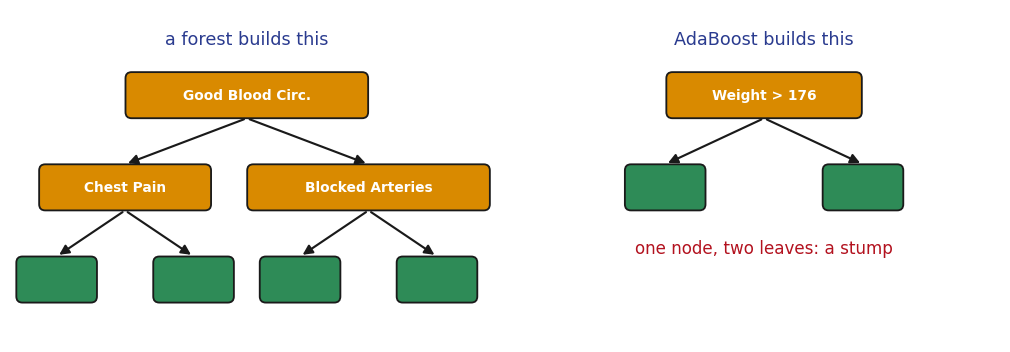

In [20]:
fig, ax = frame((11.6, 3.9), (-6.5, 6.5), (-3.3, 1.0))
note(ax, -3.4, 0.62, "a forest builds this", fs=11.5, ha="center", color=chh.MADRID)
node_box(ax, -3.4, -0.1, "Good Blood Circ.")
node_box(ax, -5.0, -1.3, "Chest Pain")
node_box(ax, -1.8, -1.3, "Blocked Arteries")
link(ax, (-3.4, -0.1), (-5.0, -1.3))
link(ax, (-3.4, -0.1), (-1.8, -1.3))
for x, p in ((-5.9, -5.0), (-4.1, -5.0), (-2.7, -1.8), (-0.9, -1.8)):
    link(ax, (p, -1.3), (x, -2.5))
    node_box(ax, x, -2.5, "     ", kind="leaf", w=0.9)

note(ax, 3.4, 0.62, "AdaBoost builds this", fs=11.5, ha="center", color=chh.MADRID)
node_box(ax, 3.4, -0.1, "Weight > 176")
for x in (2.1, 4.7):
    link(ax, (3.4, -0.1), (x, -1.3))
    node_box(ax, x, -1.3, "     ", kind="leaf", w=0.9)
note(ax, 3.4, -2.1, "one node, two leaves: a stump", fs=11, ha="center",
     color=chh.FITLINE)

### Two: The Votes Are Not Equal

Every tree in a forest gets one vote. Every stump in AdaBoost gets an
<b style="color:#73000A;">amount of say</b>. Better stumps get higher weight.

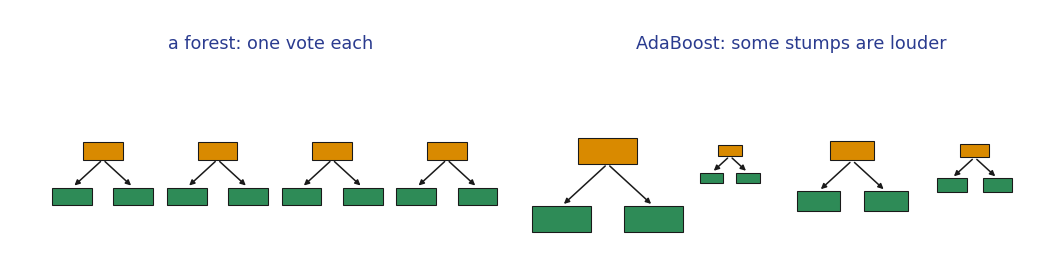

In [21]:
fig, ax = frame((12.2, 2.9), (-6.8, 6.8), (-1.7, 1.1))
note(ax, -3.4, 0.72, "a forest: one vote each", fs=11.5, ha="center",
     color=chh.MADRID)
for k in range(4):
    mini_stump(ax, -5.6 + 1.5 * k, -0.5, scale=1.0)
note(ax, 3.4, 0.72, "AdaBoost: some stumps are louder", fs=11.5, ha="center",
     color=chh.MADRID)
for k, s in enumerate((1.5, 0.6, 1.1, 0.75)):
    mini_stump(ax, 1.0 + 1.6 * k, -0.5, scale=s)

### Three: Order Matters

A forest could build its trees in any order, or all at once. AdaBoost cannot.
The mistakes the first stump makes decide how the second one is built.

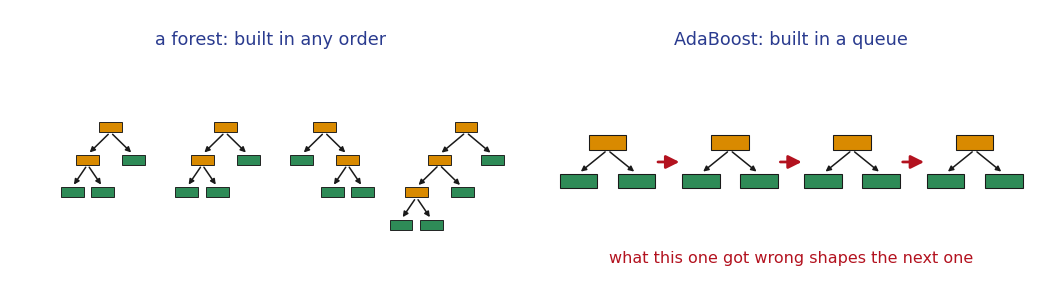

In [22]:
fig, ax = frame((12.2, 3.2), (-6.8, 6.8), (-2.4, 1.1))
note(ax, -3.4, 0.72, "a forest: built in any order", fs=11.5, ha="center",
     color=chh.MADRID)
for k in range(4):
    mini_tree(ax, -5.6 + 1.5 * k, -0.4, seed=31 + 5 * k, pitch=0.40, drop=0.42,
              bw=0.30, bh=0.13)
note(ax, 3.4, 0.72, "AdaBoost: built in a queue", fs=11.5, ha="center",
     color=chh.MADRID)
for k in range(4):
    mini_stump(ax, 1.0 + 1.6 * k, -0.6, scale=0.95)
    if k:
        ax.annotate("", xy=(1.0 + 1.6 * k - 0.62, -0.85),
                    xytext=(1.0 + 1.6 * (k - 1) + 0.62, -0.85), zorder=7,
                    arrowprops=dict(arrowstyle="-|>", color=chh.FITLINE, lw=1.8))
note(ax, 3.4, -2.1, "what this one got wrong shapes the next one", fs=10.5,
     ha="center", color=chh.FITLINE)

### New Column

Eight patients. The <b style="color:#B0286B;">sample weight</b> says how badly we want this patient
classified correctly. At the start nobody is special, so every weight is one
over eight.

{'left': 0.0,
 'right': 7.1,
 'top': 0.0,
 'bottom': -5.21,
 'cw': 1.42,
 'rh': 0.52,
 'hh': 1.05,
 'row': <function __main__.data_table.<locals>.<lambda>(i)>,
 'col': <function __main__.data_table.<locals>.<lambda>(j)>}

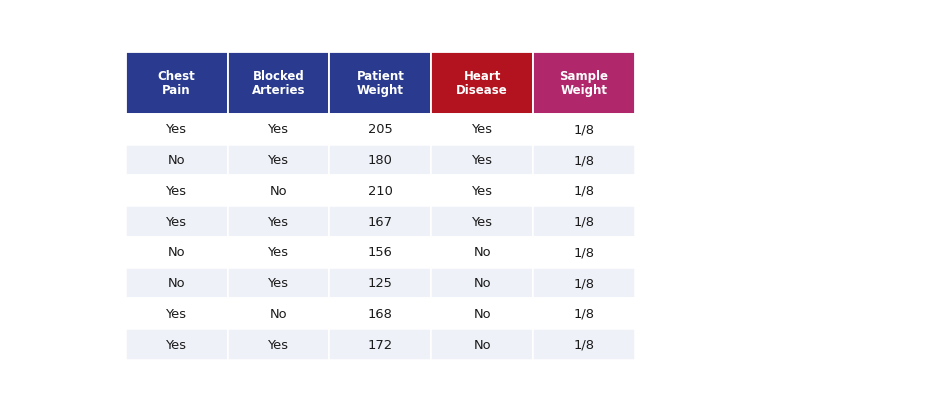

In [23]:
fig, ax = frame((10.6, 4.4), (-1.6, 11.0), (-5.6, 0.7))
rows = [r + ("1/8",) for r in AB_ROWS]
data_table(ax, rows, head=AB_HEAD, left=0.0, top=0.0, target=3, cw=1.42,
           rh=0.52, head_colors={4: AB_PINK})

### Which of the Three Makes the Best Stump?

- Use Gini impurity. Lowest wins.
- Notice the outcome is correctness...

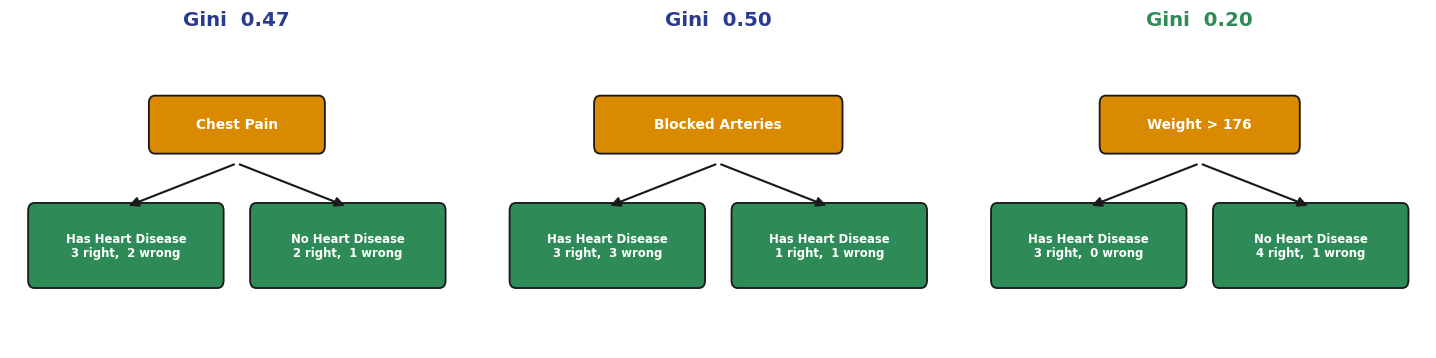

In [24]:
CP = [(3, 2), (1, 2)]          # chest pain yes, chest pain no
BA = [(3, 3), (1, 1)]          # blocked arteries yes, no
PW = [(3, 0), (1, 4)]          # weight over 176, weight under

fig, axes = plt.subplots(1, 3, figsize=(13.4, 3.6), dpi=110)
fig.patch.set_facecolor("white")
spec = (("Chest Pain", CP,
         ("Has Heart Disease", 3, 2), ("No Heart Disease", 2, 1)),
        ("Blocked Arteries", BA,
         ("Has Heart Disease", 3, 3), ("Has Heart Disease", 1, 1)),
        ("Weight > 176", PW,
         ("Has Heart Disease", 3, 0), ("No Heart Disease", 4, 1)))
scores = [gini(g) for _, g, _, _ in spec]
win = int(np.argmin(scores))
for k, (ax, (q, g, lf, rt)) in enumerate(zip(axes, spec)):
    blank_ax(ax)
    ax.set_xlim(-2.9, 2.9)
    ax.set_ylim(-2.3, 0.9)
    stump(ax, 0.0, 0.0, q, lf, rt, gap=2.85, lw=2.35)
    ax.set_title("Gini  %.2f" % scores[k], fontsize=13, weight="bold", pad=8,
                 color="#2E8B57" if k == win else chh.MADRID)
fig.tight_layout()

### The Stump Gets One Patient Wrong

The patient who weighs 167 has heart disease. The stump says they do not.
<b style="color:#73000A;">Total error</b> is the sample weight of everyone it gets wrong, so here it is
one eighth.

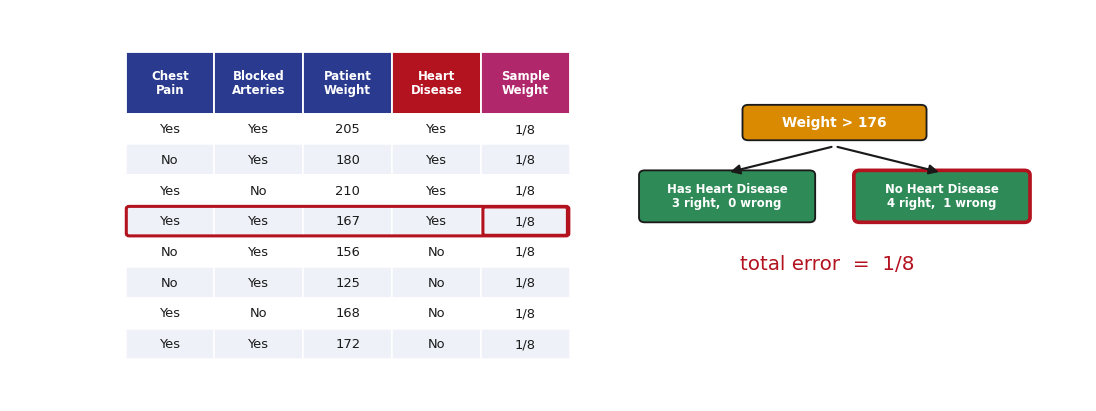

In [25]:
fig, ax = frame((12.6, 4.6), (-1.6, 13.4), (-5.9, 0.7))
rows = [r + ("1/8",) for r in AB_ROWS]
data_table(ax, rows, head=AB_HEAD, left=0.0, top=0.0, target=3, cw=1.24,
           rh=0.52, head_colors={4: AB_PINK}, ring_rows=[AB_WRONG],
           ring_cells=[(AB_WRONG, 4)])
stump(ax, 9.9, -1.2, "Weight > 176", ("Has Heart Disease", 3, 0),
      ("No Heart Disease", 4, 1), gap=3.0, lw=2.3, hot=1)
note(ax, 9.8, -3.6, "total error  =  1/8", fs=13, ha="center",
     color=chh.FITLINE)

### How Much Say Does It Get?

$$\text{amount of say} \;=\; \tfrac{1}{2}\,\log\!\left(\frac{1-\text{total error}}{\text{total error}}\right)$$

- A stump that is almost always right gets a large positive say. 
- A stump no better than a coin gets nothing. 
- A stump that is almost always wrong gets a large **negative** say.

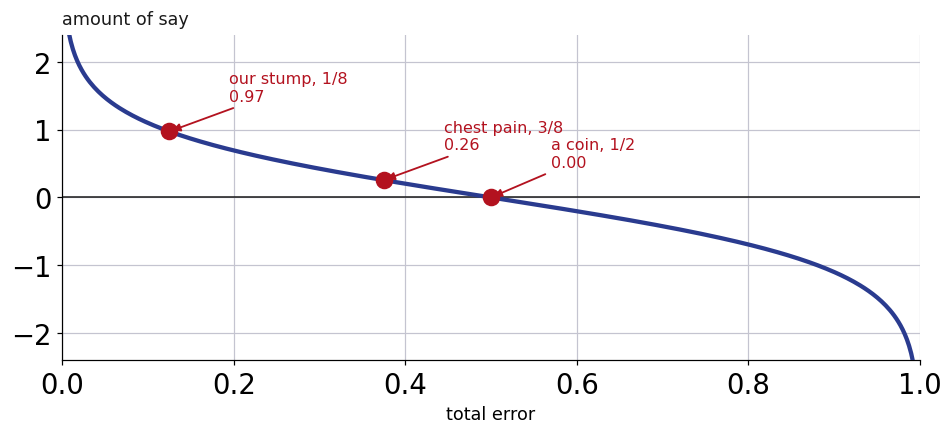

In [26]:
e = np.linspace(0.005, 0.995, 400)
fig, ax = plt.subplots(figsize=(9.0, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=chh.GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.axhline(0, color=chh.INK, lw=1.0, zorder=2)
ax.plot(e, say(e), lw=2.8, color=chh.MADRID, zorder=4)
for te, lab in ((1 / 8, "our stump, 1/8"), (3 / 8, "chest pain, 3/8"),
                (0.5, "a coin, 1/2")):
    ax.scatter([te], [say(te)], s=110, color=chh.FITLINE, zorder=6)
    ax.annotate("%s\n%.2f" % (lab, say(te)), xy=(te, say(te)),
                xytext=(te + 0.07, say(te) + 0.45), fontsize=10.5,
                color=chh.FITLINE, zorder=8,
                arrowprops=dict(arrowstyle="-|>", color=chh.FITLINE, lw=1.2))
ax.set_xlim(0, 1)
ax.set_ylim(-2.4, 2.4)
ax.set_xlabel("total error", fontsize=11.5)
ax.text(0, 1.02, "amount of say", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=11.5, color=chh.INK)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()

### The Losing Stump

Chest pain gets three patients wrong, so its total error is three eighths and
its say would have been <b style="color:#73000A;">0.26</b>, against <b style="color:#73000A;">0.97</b> for the stump that won.

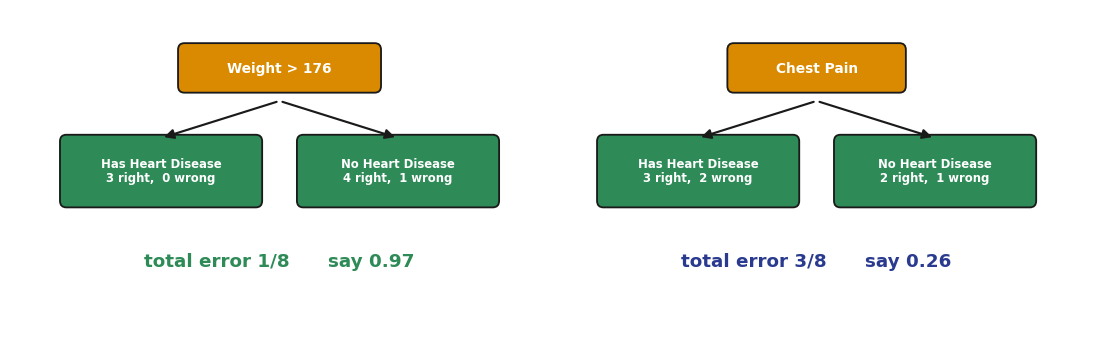

In [27]:
fig, ax = frame((12.6, 3.8), (-6.8, 6.8), (-2.9, 1.0))
for cx, q, lf, rt, te in ((-3.4, "Weight > 176", ("Has Heart Disease", 3, 0),
                           ("No Heart Disease", 4, 1), 1 / 8),
                          (3.4, "Chest Pain", ("Has Heart Disease", 3, 2),
                           ("No Heart Disease", 2, 1), 3 / 8)):
    stump(ax, cx, 0.3, q, lf, rt, gap=3.0, lw=2.4)
    ax.text(cx, -2.1, "total error %s      say %.2f"
            % ("1/8" if te < 0.2 else "3/8", say(te)), ha="center",
            fontsize=12, weight="bold",
            color="#2E8B57" if te < 0.2 else chh.MADRID)

### Now Change the Weights

The stump got the 167-pound patient wrong, so make that patient matter more to
the next stump and everybody else matter less.

$$
\begin{aligned}
\text{The one it got wrong:}\qquad
& w_{\text{new}} = w_{\text{old}} \times e^{+\text{amount of say}} \\[4pt]
& \tfrac{1}{8} \times e^{+0.97}
= \tfrac{1}{8} \times 2.64
= 0.33
\end{aligned}
$$

$$
\begin{aligned}
\text{Everybody else:}\qquad
& w_{\text{new}} = w_{\text{old}} \times e^{-\text{amount of say}} \\[4pt]
& \tfrac{1}{8} \times e^{-0.97}
= \tfrac{1}{8} \times 0.38
= 0.05
\end{aligned}
$$

### Add Them Up and Divide

The eight new weights come to 0.68, not 1. Divide each by 0.68 and they add up
again. The patient the stump got wrong now carries <b style="color:#73000A;">0.49</b> of the total, and
the other seven share what is left.

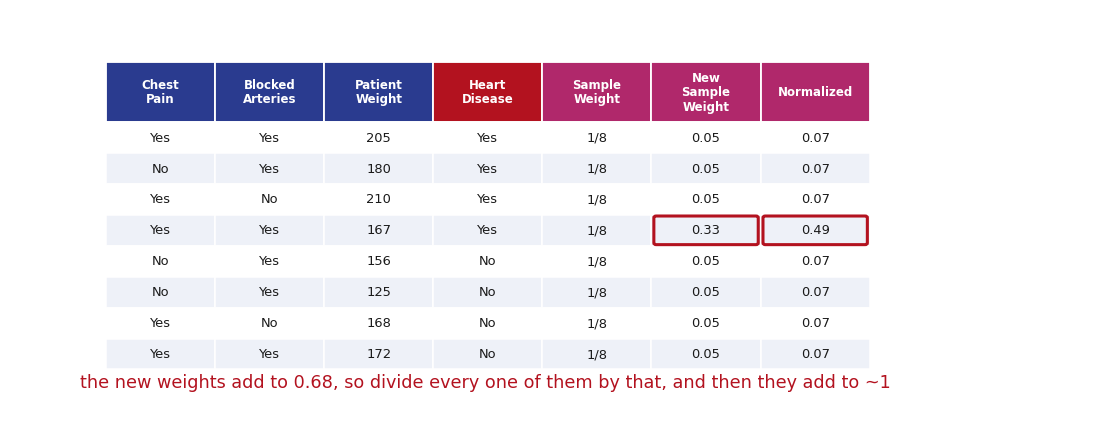

In [28]:
sc_up, sc_dn = np.exp(say(1 / 8)), np.exp(-say(1 / 8))
raw = [round(1 / 8 * (sc_up if i == AB_WRONG else sc_dn), 2) for i in range(8)]
tot = round(sum(raw), 2)
new = [round(r / tot, 2) for r in raw]

HEAD2 = AB_HEAD + ["New\nSample\nWeight", "Normalized"]
rows = [AB_ROWS[i] + ("1/8", "%.2f" % raw[i], "%.2f" % new[i])
        for i in range(8)]
fig, ax = frame((12.8, 4.8), (-1.2, 12.6), (-6.2, 0.9))
data_table(ax, rows, head=HEAD2, left=0.0, top=0.0, target=3, cw=1.38,
           rh=0.54, head_colors={4: AB_PINK, 5: AB_PINK, 6: AB_PINK},
           ring_cells=[(AB_WRONG, 5), (AB_WRONG, 6)])
note(ax, 4.8, -5.6, "the new weights add to %.2f, so divide every one of them "
     "by that, and then they add to ~1" % (tot), fs=11.5,
     ha="center", color=chh.FITLINE)

### Using Our New Weights

Treat the weights as a distribution over the eight patients, draw eight times
from it, and build the next stump on what you drew.

This is <b style="color:#73000A;">not</b> the bootstrap from the first section. That drew everybody with
equal probability, to make the trees differ. This draws in proportion to the
weights, to make the next stump care.

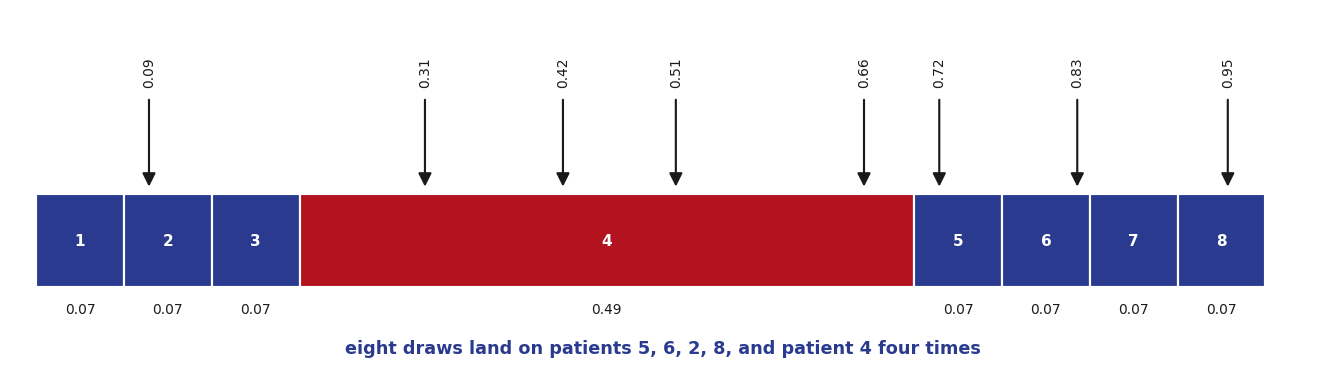

In [29]:
sc_up, sc_dn = np.exp(say(1 / 8)), np.exp(-say(1 / 8))
raw = [round(1 / 8 * (sc_up if i == AB_WRONG else sc_dn), 2) for i in range(8)]
tot = round(sum(raw), 2)
w = np.array([round(r / tot, 2) for r in raw])      # the same 0.49 and 0.07
edge = np.concatenate([[0], np.cumsum(w)])
DRAWS = [0.72, 0.42, 0.83, 0.51, 0.31, 0.66, 0.09, 0.95]

fig, ax = plt.subplots(figsize=(12.4, 3.9), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
for i in range(8):
    ax.add_patch(plt.Rectangle((edge[i], 0), w[i], 0.42, zorder=3,
                               facecolor=chh.FITLINE if i == AB_WRONG else chh.MADRID,
                               edgecolor="white", lw=1.4))
    ax.text((edge[i] + edge[i + 1]) / 2, 0.21, "%d" % (i + 1), ha="center",
            va="center", fontsize=10, color="white", weight="bold", zorder=4)
    ax.text((edge[i] + edge[i + 1]) / 2, -0.07, "%.2f" % w[i], ha="center",
            va="top", fontsize=9, color=chh.INK)
for d in DRAWS:
    ax.annotate("", xy=(d, 0.44), xytext=(d, 0.86), zorder=6,
                arrowprops=dict(arrowstyle="-|>", color=chh.INK, lw=1.4))
    ax.text(d, 0.90, "%.2f" % d, ha="center", va="bottom", fontsize=9,
            color=chh.INK, rotation=90)

hit = [int(np.searchsorted(edge, d) - 1) for d in DRAWS]
other_hits = [str(h + 1) for h in hit if h + 1 != 4]

ax.text(
    0.5, -0.30,
    "eight draws land on patients %s, and patient 4 four times"
    % ", ".join(other_hits),
    ha="center", fontsize=11.5,
    color=chh.MADRID, weight="bold",
)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.42, 1.25)
ax.axis("off")
fig.tight_layout()

### How the Forest of Stumps Votes

Add up the amount of say of every stump that says yes, and of every stump that
says no. The bigger sum wins.

Not one vote each, the way the forest did it. And every stump stays in: a new
stump <b style="color:#73000A;">joins</b> the older ones, it never replaces them.

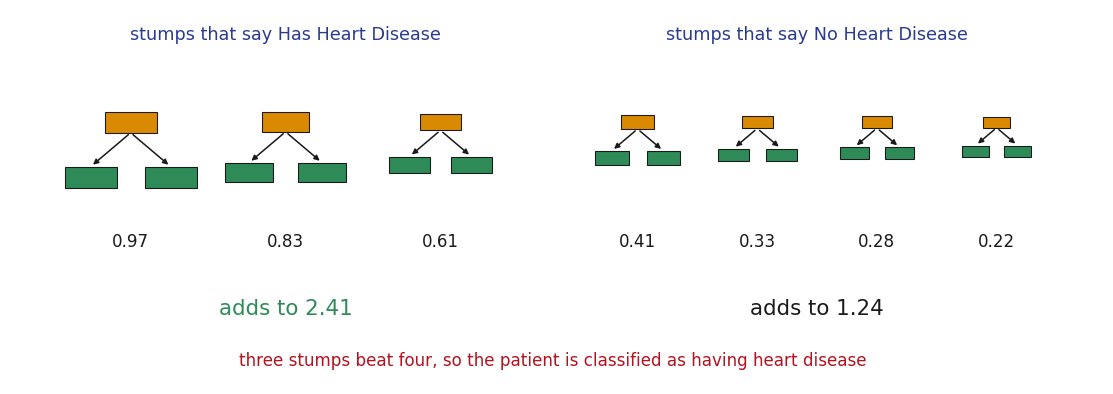

In [30]:
YES = [0.97, 0.83, 0.61]
NO = [0.41, 0.33, 0.28, 0.22]
fig, ax = frame((12.8, 4.4), (-0.9, 14.6), (-3.9, 1.1))
note(ax, 3.0, 0.78, "stumps that say Has Heart Disease", fs=11.5, ha="center",
     color=chh.MADRID)
for k, s in enumerate(YES):
    mini_stump(ax, 0.8 + 2.2 * k, -0.4, scale=0.55 + 0.9 * s)
    note(ax, 0.8 + 2.2 * k, -2.0, "%.2f" % s, fs=11, ha="center", color=chh.INK)
note(ax, 10.55, 0.78, "stumps that say No Heart Disease", fs=11.5, ha="center",
     color=chh.MADRID)
for k, s in enumerate(NO):
    mini_stump(ax, 8.0 + 1.7 * k, -0.4, scale=0.55 + 0.9 * s)
    note(ax, 8.0 + 1.7 * k, -2.0, "%.2f" % s, fs=11, ha="center", color=chh.INK)
note(ax, 3.0, -2.9, "adds to %.2f" % sum(YES), fs=14, ha="center",
     color="#2E8B57")
note(ax, 10.55, -2.9, "adds to %.2f" % sum(NO), fs=14, ha="center",
     color=chh.INK)
note(ax, 6.8, -3.6, "three stumps beat four, so the patient is classified as "
     "having heart disease", fs=11, ha="center", color=chh.FITLINE)

### AdaBoost, All of It

1. Give every patient the same sample weight
2. Find the stump with the lowest Gini, using those weights
3. Its <b style="color:#73000A;">amount of say</b> is $\tfrac12\log\frac{1-\text{total error}}{\text{total error}}$
4. Raise the weight on whoever it got wrong, lower everyone else, and rescale to add to one
5. Go back to step 2. The next stump <b style="color:#73000A;">joins</b> the others, it does not replace them
6. To classify, add the says on each side and take the bigger sum


### AdaBoost in scikit-learn

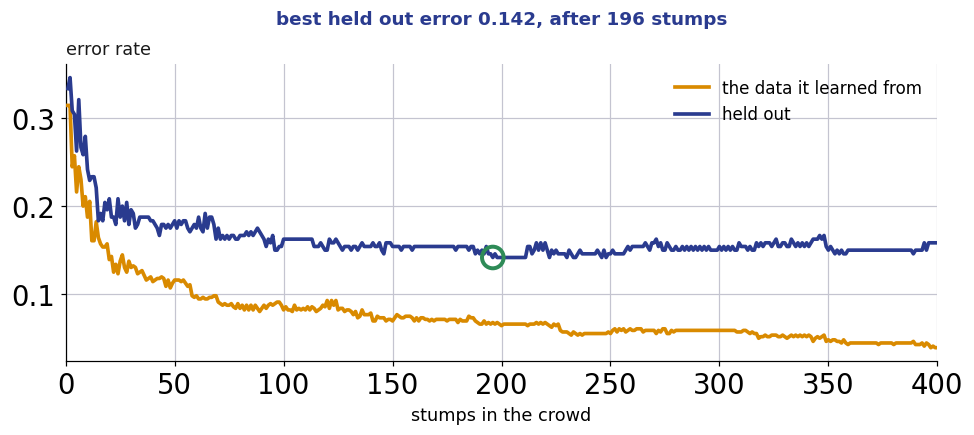

In [31]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split

X, y = loan_data()
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
ada = AdaBoostClassifier(n_estimators=400, learning_rate=0.5,
                         random_state=0).fit(Xtr, ytr)
tr = [1 - s for s in ada.staged_score(Xtr, ytr)]
te = [1 - s for s in ada.staged_score(Xte, yte)]
k = int(np.argmin(te)) + 1

fig, ax = plt.subplots(figsize=(9.2, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=chh.GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.plot(range(1, len(tr) + 1), tr, lw=2.4, color=chh.ACCENT, zorder=4,
        label="the data it learned from")
ax.plot(range(1, len(te) + 1), te, lw=2.4, color=chh.MADRID, zorder=4,
        label="held out")
ax.scatter([k], [min(te)], s=200, facecolors="none", edgecolors="#2E8B57",
           lw=2.6, zorder=6)
ax.legend(frameon=False, fontsize=11, loc="upper right")
ax.set_xlabel("stumps in the crowd", fontsize=11.5)
ax.set_title("best held out error %.3f, after %d stumps" % (min(te), k),
             fontsize=12, color=chh.MADRID, weight="bold", pad=26)
ax.text(0, 1.02, "error rate", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=11.5, color=chh.INK)
ax.set_xlim(0, len(te))
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()

In [32]:
# His six people, and the tree he fits to their leftovers. Everything on the
# gradient boosting slides is worked out from these six rows.
GB_HEAD = ["Height\n(m)", "Favorite\nColor", "Gender", "Weight\n(kg)"]
GB_ROWS = [(1.6, "Blue",  "Male",   88),
           (1.6, "Green", "Female", 76),
           (1.5, "Blue",  "Female", 56),
           (1.8, "Red",   "Male",   73),
           (1.5, "Green", "Male",   77),
           (1.4, "Blue",  "Female", 57)]
GB_W = np.array([r[3] for r in GB_ROWS], float)
GB_H = np.array([r[0] for r in GB_ROWS], float)
GB_C = [r[1] for r in GB_ROWS]
GB_F = np.array([r[2] == "Female" for r in GB_ROWS])

# the four leaves of his tree, as masks over the six rows
GB_LEAF = [("female, height < 1.6", GB_F & (GB_H < 1.6)),
           ("female, height 1.6 up", GB_F & (GB_H >= 1.6)),
           ("male, colour not blue", ~GB_F & np.array([c != "Blue" for c in GB_C])),
           ("male, colour blue", ~GB_F & np.array([c == "Blue" for c in GB_C]))]


def gb_round(pred, rate):
    """One round: leftovers, a tree with four leaves, a step of size rate."""
    resid = GB_W - pred
    out = np.zeros(6)
    for _, m in GB_LEAF:
        out[m] = resid[m].mean()
    return resid, out, pred + rate * out


def gb_tree(ax, cx, cy, leaf_vals, gap=4.6, drop=1.15, hot=None, fs=8.5):
    """His tree, drawn with whatever numbers the leaves hold this round."""
    node_box(ax, cx, cy, "Gender = Female", fs=fs + 0.5)
    kids = []
    for s, q in ((-1, "Height < 1.6"), (1, "Colour not Blue")):
        x = cx + s * gap / 2
        node_box(ax, x, cy - drop, q, fs=fs)
        link(ax, (cx, cy), (x, cy - drop), "True" if s < 0 else "False")
        kids.append(x)
    made = []
    for k, (x, v) in enumerate(zip(
            (kids[0] - gap / 4, kids[0] + gap / 4,
             kids[1] - gap / 4, kids[1] + gap / 4), leaf_vals)):
        parent = kids[0] if k < 2 else kids[1]
        link(ax, (parent, cy - drop), (x, cy - 2 * drop),
             "True" if k % 2 == 0 else "False")
        node_box(ax, x, cy - 2 * drop, "%.1f" % v, kind="leaf", w=1.15,
                 fs=fs + 1.5, ring=(hot == k))
        made.append(x)
    return made

## Gradient Boosting: Fit the Leftovers

Three things change from AdaBoost:

- it starts from <b style="color:#73000A;">one number</b> rather than a stump
- the trees are <b style="color:#73000A;">bigger than stumps</b>, though still capped. Four leaves here, eight to 32 on real data
- every tree is scaled by the <b style="color:#73000A;">same</b> amount, not by its own amount of say

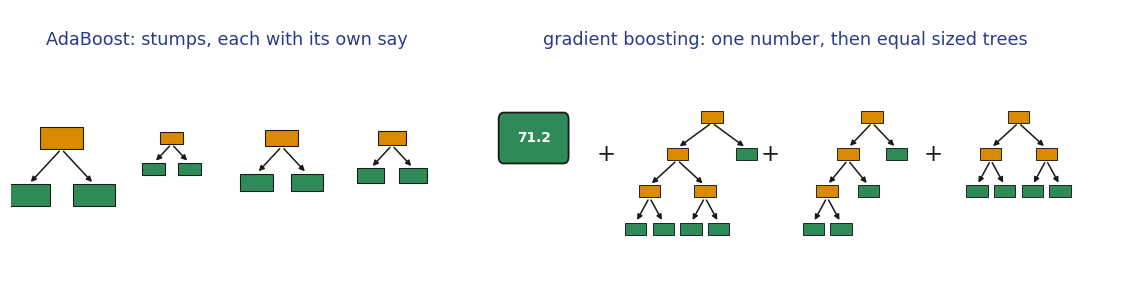

In [33]:
fig, ax = frame((13.0, 3.2), (-7.4, 10.2), (-2.0, 1.2))
note(ax, -3.97, 0.86, "AdaBoost: stumps, each with its own say", fs=11.5,
     ha="center", color=chh.MADRID)
for k, s in enumerate((1.3, 0.7, 1.0, 0.85)):
    mini_stump(ax, -6.6 + 1.75 * k, -0.3, scale=s)

note(ax, 4.9, 0.86, "gradient boosting: one number, then equal sized trees",
     fs=11.5, ha="center", color=chh.MADRID)
node_box(ax, 0.9, -0.3, "71.2", kind="leaf", w=0.95, fs=9)
for k in range(3):
    mini_tree(ax, 3.4 + 2.6 * k, -0.05, seed=51 + 9 * k, pitch=0.44, drop=0.44,
              bw=0.34, bh=0.14)
    ax.text(2.05 + 2.6 * k, -0.5, "+", ha="center", va="center", fontsize=15,
            color=chh.INK)

### Start With One Number

Six people, and we want to predict weight. The first prediction is the average
weight, <b style="color:#73000A;">71.2</b> kg, for everybody.

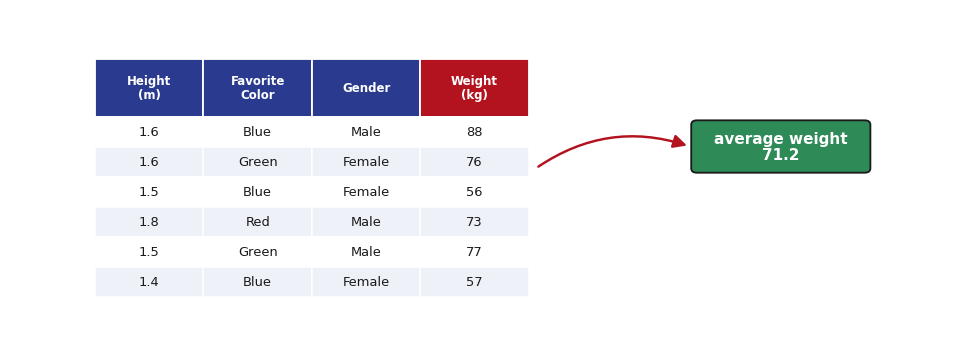

In [34]:
fig, ax = frame((11.0, 3.8), (-1.2, 12.2), (-5.0, 0.9))
rows = [(("%.1f" % r[0]), r[1], r[2], str(r[3])) for r in GB_ROWS]
data_table(ax, rows, head=GB_HEAD, left=0.0, top=0.0, target=3, cw=1.55,
           rh=0.55)
node_box(ax, 9.8, -1.6, "average weight\n%.1f" % GB_W.mean(), kind="leaf",
         w=2.4, h=0.80, fs=10)
curve(ax, (6.3, -2.0), (8.5, -1.6), rad=-0.25)

### What Is Left Over

Subtract 71.2 from each observed weight. 
- We can call this a <b style="color:#73000A;">pseudo residual</b>
  - Same idea as from regression

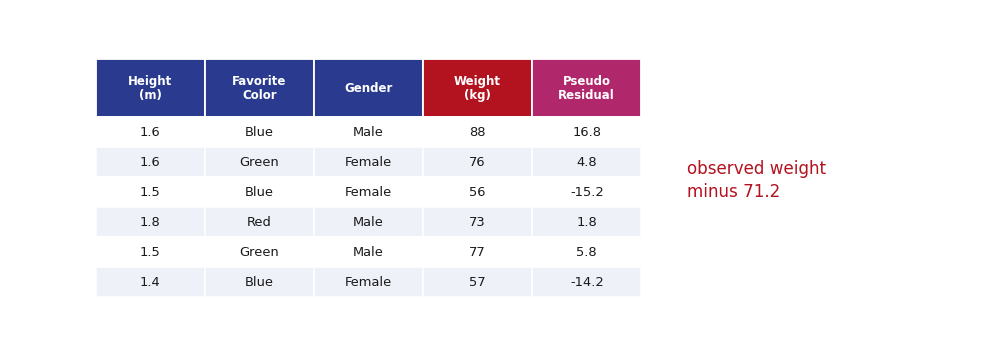

In [35]:
r0 = GB_W - GB_W.mean()
fig, ax = frame((11.4, 3.8), (-1.2, 12.6), (-5.0, 0.9))
rows = [(("%.1f" % GB_ROWS[i][0]), GB_ROWS[i][1], GB_ROWS[i][2],
         str(GB_ROWS[i][3]), "%.1f" % r0[i]) for i in range(6)]
data_table(ax, rows, head=GB_HEAD + ["Pseudo\nResidual"], left=0.0, top=0.0,
           target=3, cw=1.55, rh=0.55, head_colors={4: AB_PINK})
note(ax, 8.4, -2.2, "observed weight\nminus 71.2", fs=11, color=chh.FITLINE)

### Build a Tree on the Leftovers

- Height, colour and gender, predicting the residual column. 
- Four leaves at most, so two of the leaves hold two people each and take their average.

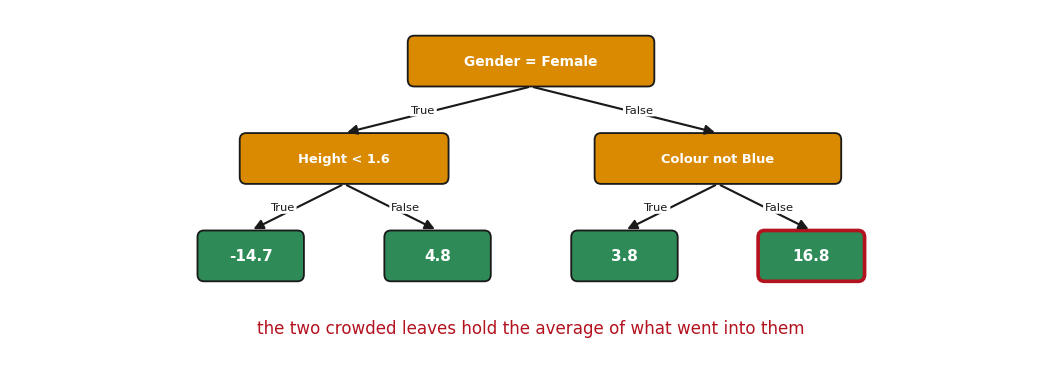

In [36]:
r0, out0, _ = gb_round(np.full(6, GB_W.mean()), 0.1)
fig, ax = frame((12.2, 4.2), (-6.4, 6.4), (-3.2, 1.0))
gb_tree(ax, 0.0, 0.4, [out0[m][0] for _, m in GB_LEAF], hot=3)
note(ax, 0.0, -2.75, "the two crowded leaves hold the average of what went into them",
     fs=11, ha="center", color=chh.FITLINE)

### Add the Tree to the Number

The person in the ringed leaf weighs 88. Start at 71.2, run them down the
tree, pick up 16.8, and the prediction is <b style="color:#73000A;">88</b>, his own weight.

Is that good?

No.

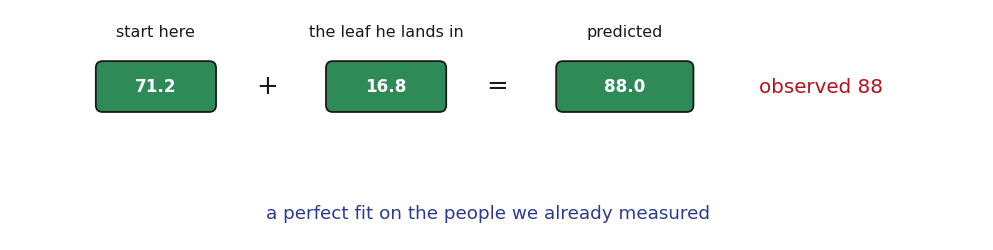

In [37]:
r0, out0, _ = gb_round(np.full(6, GB_W.mean()), 0.1)
base = GB_W.mean()
fig, ax = frame((11.4, 2.7), (-5.6, 5.8), (-1.5, 1.2))
node_box(ax, -3.9, 0.3, "%.1f" % base, kind="leaf", w=1.25, fs=11)
note(ax, -3.9, 0.95, "start here", fs=10.5, ha="center", color=chh.INK)
ax.text(-2.6, 0.3, "+", ha="center", va="center", fontsize=17, color=chh.INK)
node_box(ax, -1.2, 0.3, "%.1f" % out0[0], kind="leaf", w=1.25, fs=11)
note(ax, -1.2, 0.95, "the leaf he lands in", fs=10.5, ha="center", color=chh.INK)
ax.text(0.1, 0.3, "=", ha="center", va="center", fontsize=17, color=chh.INK)
node_box(ax, 1.6, 0.3, "%.1f" % (base + out0[0]), kind="leaf", w=1.45, fs=11)
note(ax, 1.6, 0.95, "predicted", fs=10.5, ha="center", color=chh.INK)
note(ax, 3.9, 0.3, "observed 88", fs=13, ha="center", color=chh.FITLINE)
note(ax, 0.0, -1.2, "a perfect fit on the people we already measured", fs=12, ha="center",
     color=chh.MADRID)

### Take a Small Step Instead

Scale the tree by a <b style="color:#73000A;">learning rate</b> before adding it. With a rate of 0.1:

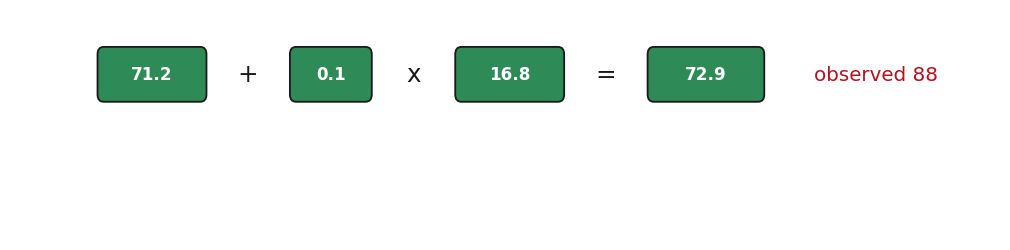

In [38]:
base = GB_W.mean()
r0, out0, p1 = gb_round(np.full(6, base), 0.1)
fig, ax = frame((11.6, 2.7), (-6.4, 6.4), (-1.5, 1.0))
bits = [("%.1f" % base, 1.25), ("+", 0), ("0.1", 0.9), ("x", 0),
        ("%.1f" % out0[0], 1.25), ("=", 0), ("%.1f" % p1[0], 1.35)]
x = -5.2
for lab, w in bits:
    x += w / 2
    if w:
        node_box(ax, x, 0.3, lab, kind="leaf", w=w, fs=11)
    else:
        ax.text(x, 0.3, lab, ha="center", va="center", fontsize=16,
                color=chh.INK)
    x += w / 2 + 0.62
note(ax, x + 0.9, 0.3, "observed 88", fs=13, ha="center", color=chh.FITLINE)


### Do It Again

New prediction, new leftovers, new tree. The person who was 16.8 out is now
<b style="color:#73000A;">15.1</b> out, and after the second tree the prediction is 74.4.

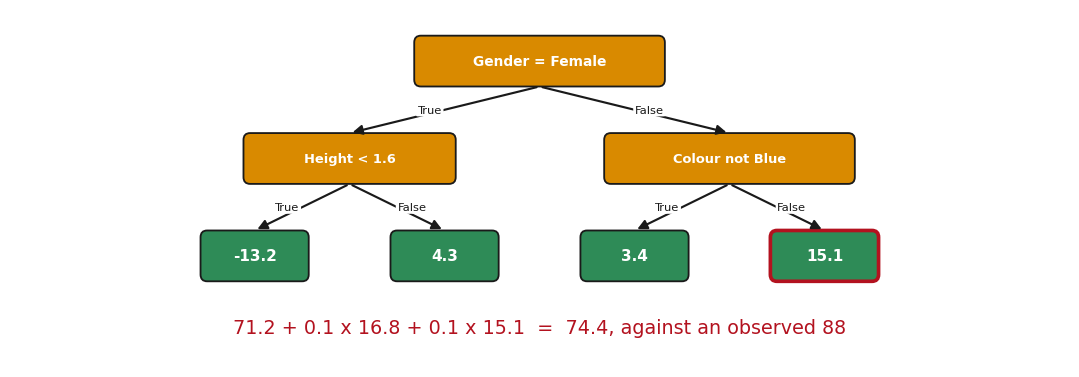

In [39]:
base = np.full(6, GB_W.mean())
r0, out0, p1 = gb_round(base, 0.1)
r1, out1, p2 = gb_round(p1, 0.1)
fig, ax = frame((12.4, 4.2), (-6.4, 6.4), (-3.2, 1.0))
gb_tree(ax, 0.0, 0.4, [out1[m][0] for _, m in GB_LEAF], hot=3)
note(ax, 0.0, -2.75,
     "%.1f + 0.1 x %.1f + 0.1 x %.1f  =  %.1f, against an observed 88"
     % (GB_W.mean(), out0[0], out1[0], p2[0]), fs=12.5, ha="center",
     color=chh.FITLINE)

### The Pseudo-Residuals Shrink Every Round

Every column is what is still missing after one more tree. Nothing is ever
thrown away, it is just added to.

### Use It: Somebody New Walks In

A woman, 1.5 m tall, favourite colour blue. Start at the average and add each
tree's leaf in turn, every one of them scaled by the learning rate.

$$71.2 \;+\; 0.1\times(-14.7) \;+\; 0.1\times(-13.2) \;+\; 0.1\times(-11.9) \;+\; \dots$$

Five trees in, the prediction is <b style="color:#73000A;">65.2</b> kg...

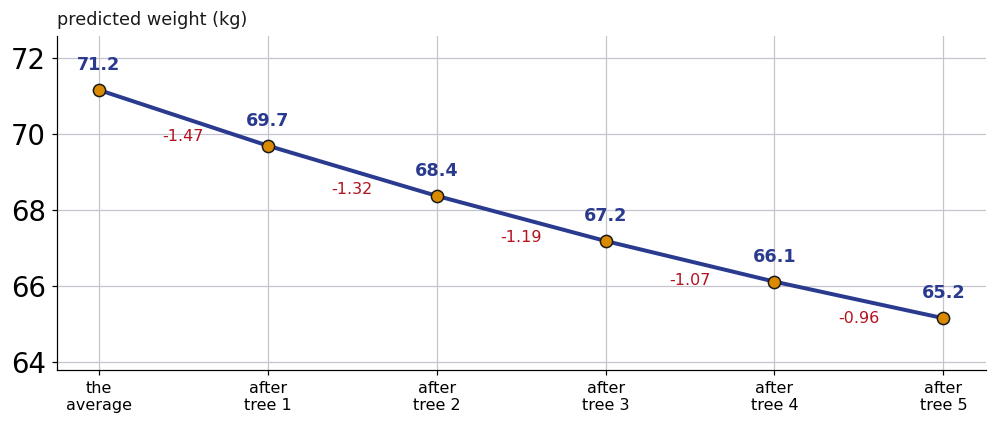

In [40]:
rate = 0.1
pred = np.full(6, GB_W.mean())
path = [GB_W.mean()]          # the new woman: female, 1.5 m, so leaf 0 every time
steps = []
for _ in range(5):
    _, out, pred = gb_round(pred, rate)
    leaf = out[GB_LEAF[0][1]][0]
    steps.append(leaf)
    path.append(path[-1] + rate * leaf)

fig, ax = plt.subplots(figsize=(9.4, 4.2), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=chh.GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.plot(range(len(path)), path, color=chh.MADRID, lw=2.6, marker="o",
        markersize=8, markerfacecolor=chh.ACCENT, markeredgecolor=chh.INK,
        zorder=5)
for k, v in enumerate(path):
    ax.text(k, v + 0.42, "%.1f" % v, ha="center", va="bottom", fontsize=11.5,
            color=chh.MADRID, weight="bold", zorder=8)
for k, s in enumerate(steps):
    ax.text(k + 0.5, (path[k] + path[k + 1]) / 2 - 0.30, "%+.2f" % (rate * s),
            ha="center", va="top", fontsize=10.5, color=chh.FITLINE, zorder=8)
ax.set_xticks(range(len(path)))
ax.set_xticklabels(["the\naverage"] + ["after\ntree %d" % k
                                       for k in range(1, len(path))],
                   fontsize=10.5)
ax.set_ylim(63.8, 72.6)
ax.text(0, 1.02, "predicted weight (kg)", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=11.5, color=chh.INK)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()

### The Same Thing on Last Week's Patients

Nineteen patients, dose against effectiveness, and a boosted model with two
level trees at a rate of 0.1. Watch it find the shape one small step at a time.

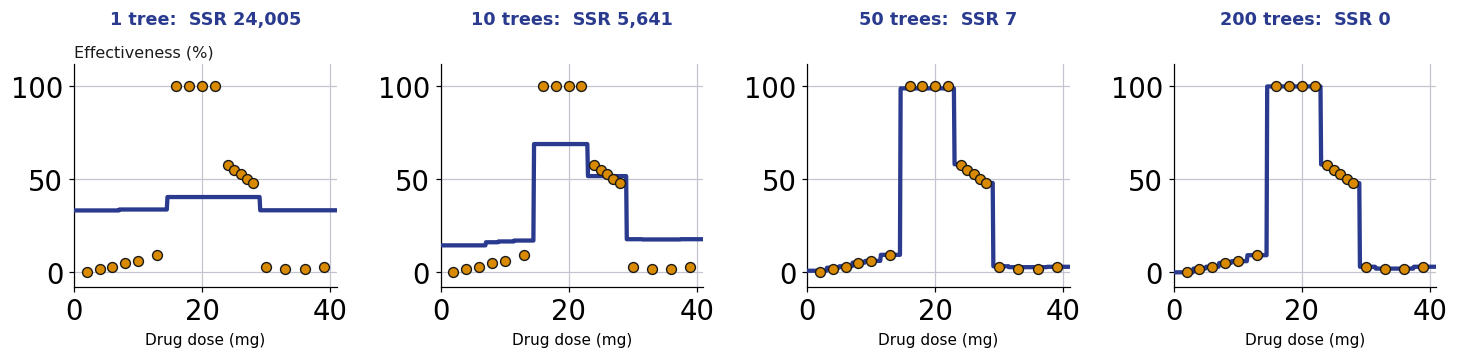

In [41]:
from sklearn.ensemble import GradientBoostingRegressor

x, y = mlh._DT_DOSE.reshape(-1, 1), mlh._DT_EFF
g = np.linspace(0, 41, 400).reshape(-1, 1)
fig, axes = plt.subplots(1, 4, figsize=(13.6, 3.6), dpi=110)
fig.patch.set_facecolor("white")
for ax, n in zip(axes, (1, 10, 50, 200)):
    gb = GradientBoostingRegressor(n_estimators=n, max_depth=2,
                                   learning_rate=0.1, random_state=0).fit(x, y)
    ax.set_facecolor("white")
    ax.grid(True, color=chh.GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.plot(g.ravel(), gb.predict(g), lw=2.8, color=chh.MADRID, zorder=4)
    ax.scatter(x.ravel(), y, s=42, color=chh.ACCENT, edgecolors=chh.INK,
               lw=0.9, zorder=5)
    ax.set_title("%d tree%s:  SSR %s" % (n, "" if n == 1 else "s",
                                         format(((y - gb.predict(x)) ** 2).sum(),
                                                ",.0f")),
                 fontsize=11.5, color=chh.MADRID, weight="bold", pad=26)
    ax.set_xlabel("Drug dose (mg)", fontsize=10)
    ax.set_xlim(0, 41)
    ax.set_ylim(-8, 112)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
axes[0].text(0, 1.02, "Effectiveness (%)", transform=axes[0].transAxes,
             ha="left", va="bottom", fontsize=10.5, color=chh.INK)
fig.tight_layout()

### Two Dials, and They Pull Against Each Other

- <b style="color:#73000A;">learning rate</b>: how much of each tree you keep. Smaller is safer and slower
- <b style="color:#73000A;">n_estimators</b>: how many trees. More is better until it is not
- Halve the rate and you need roughly twice the trees to get to the same place
- Pick a small rate you can afford, then choose the number of trees by watching held out error

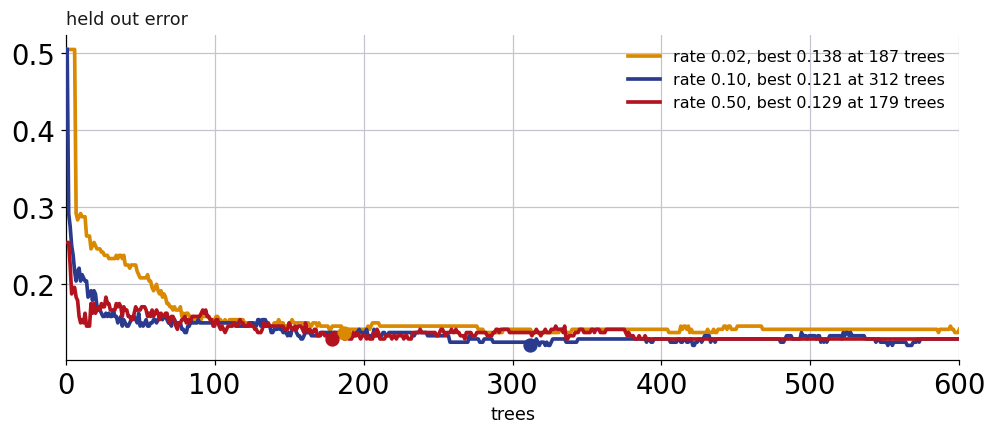

In [42]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

X, y = loan_data()
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
fig, ax = plt.subplots(figsize=(9.4, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=chh.GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
for rate, col in ((0.02, chh.ACCENT), (0.1, chh.MADRID), (0.5, chh.FITLINE)):
    gb = GradientBoostingClassifier(n_estimators=600, learning_rate=rate,
                                    max_depth=3, random_state=0).fit(Xtr, ytr)
    te = [np.mean(p != yte) for p in gb.staged_predict(Xte)]
    ax.plot(range(1, len(te) + 1), te, lw=2.4, color=col, zorder=4,
            label="rate %.2f, best %.3f at %d trees"
                  % (rate, min(te), int(np.argmin(te)) + 1))
    ax.scatter([int(np.argmin(te)) + 1], [min(te)], s=70, color=col, zorder=6)
ax.legend(frameon=False, fontsize=10.5, loc="upper right")
ax.set_xlabel("trees", fontsize=11.5)
ax.text(0, 1.02, "held out error", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=11.5, color=chh.INK)
ax.set_xlim(0, 600)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()

### Gradient Boosting in scikit-learn

In [43]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split

X, y = loan_data()
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)

gb = GradientBoostingClassifier(n_estimators=1000, learning_rate=0.05,
                                max_depth=3, n_iter_no_change=20,
                                validation_fraction=0.1,
                                random_state=0).fit(Xtr, ytr)
rf = RandomForestClassifier(n_estimators=500, max_features="sqrt",
                            random_state=0, n_jobs=-1).fit(Xtr, ytr)

print("%-40s %9s" % ("", "held out"))
print("%-40s %9s" % ("-" * 38, "-" * 8))
print("%-40s %9.3f" % ("random forest, 500 trees", rf.score(Xte, yte)))
print("%-40s %9.3f" % ("gradient boosting, stopped early", gb.score(Xte, yte)))
print()
print("boosting used %d of the 1000 trees it was offered" % gb.n_estimators_)

                                          held out
--------------------------------------    --------
random forest, 500 trees                     0.842
gradient boosting, stopped early             0.858

boosting used 139 of the 1000 trees it was offered


### Others You May Want To Know...

- <b style="color:#73000A;">XGBoost</b>: the similarity and gain above, plus second order derivatives, sparse columns handled natively, and a split finder that works out of core
- <b style="color:#73000A;">LightGBM</b>: bins every column into about 255 buckets and grows leaf by leaf instead of level by level. Much faster on wide files, and easier to overfit on small ones
- <b style="color:#73000A;">CatBoost</b>: built around categorical columns, with an ordered encoding that does not leak the outcome into its own predictor
- scikit-learn ships <b style="color:#73000A;">HistGradientBoostingClassifier</b>, which is the binned algorithm and needs no install

## Key Ideas

- One tree is unstable. Resample the rows, build a tree on each copy, and average: that is <b style="color:#73000A;">bagging</b>
- Offer each split only a random handful of columns and the trees stop agreeing with each other. That is a <b style="color:#73000A;">random forest</b>
- The third of the rows each tree never saw gives you an honest error for free: <b style="color:#73000A;">out of bag error</b>
- <b style="color:#73000A;">Boosting</b> goes the other way: build small trees in a queue, each one fitted to what the last one missed
- <b style="color:#73000A;">AdaBoost</b> reweights the rows, <b style="color:#73000A;">gradient boosting</b> fits on the residuals, and both move in small steps
- Forests are hard to overfit and easy to run. Boosting usually wins, and will overfit if you let it